In [74]:
import numpy as np
import networkx as nx
import pandas as pd
from tqdm.auto import tqdm
import itertools
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from causallearn.utils.cit import CIT
from sklearn.ensemble import RandomForestRegressor

try:
    from networkx.algorithms.d_separation import is_d_separator
except ImportError:
    from networkx.algorithms.d_separation import d_separated as is_d_separator

## Helpers

In [75]:
def markov_blanket_oracle_from_graph(G, observed_nodes, target):

    observed_nodes = list(observed_nodes)

    MB = []

    for v in observed_nodes:
        if v == target:
            continue

        conditioning_set = set(
            node for node in observed_nodes
            if node not in [target, v]
        )

        separated = is_d_separator(
            G,
            {target},
            {v},
            conditioning_set
        )

        if not separated:
            MB.append(v)

    return sorted(MB)

In [76]:
def estimate_true_effect_by_intervention(
    graph_info,
    x="X",
    y="Y",
    x0=-1.0,
    x1=1.0,
    beta=1.0,
    n_mc=100_000,
    rng=None,
    noise_scale=1.0,
):
    """
    Estimate the true causal effect contrast:

        E[Y | do(X=x1)] - E[Y | do(X=x0)]

    For linear SCMs (beta = 0), compute the exact total effect from the
    coefficient matrix. For nonlinear SCMs, use Monte Carlo intervention.
    """
    if beta == 0:
        order = graph_info["order"]
        B = graph_info["B"].loc[order, order].to_numpy(dtype=float)
        total_effect_matrix = np.linalg.inv(np.eye(len(order)) - B)

        x_idx = order.index(x)
        y_idx = order.index(y)
        effect_per_unit = total_effect_matrix[x_idx, y_idx]

        return float(effect_per_unit * (x1 - x0))

    if rng is None:
        rng = np.random.default_rng()

    # Use two child generators so the function is reproducible but independent.
    seed_0, seed_1 = rng.integers(0, 2**32 - 1, size=2)

    _, D0_full = simulate_nonlinear_scm(
        graph_info=graph_info,
        n=n_mc,
        beta=beta,
        rng=np.random.default_rng(seed_0),
        noise_scale=noise_scale,
        intervention={x: x0},
        return_full=True,
    )

    _, D1_full = simulate_nonlinear_scm(
        graph_info=graph_info,
        n=n_mc,
        beta=beta,
        rng=np.random.default_rng(seed_1),
        noise_scale=noise_scale,
        intervention={x: x1},
        return_full=True,
    )

    true_effect = D1_full[y].mean() - D0_full[y].mean()

    return true_effect


In [77]:
def estimate_effect_gformula(
    D_obs,
    x="X",
    y="Y",
    Z=None,
    x0=None,
    x1=None,
    model=None,
    random_state=0,
    estimator="auto",
    beta=None,
):
    """
    Estimate an adjustment effect using either a linear OLS estimator or a
    nonlinear random-forest g-formula estimator.

    If estimator="auto", use OLS when beta == 0 and random forest otherwise.
    """
    if Z is None:
        Z = []

    if x0 is None:
        x0 = D_obs[x].quantile(0.25)

    if x1 is None:
        x1 = D_obs[x].quantile(0.75)

    Z = list(Z)
    features = [x] + Z

    if estimator == "auto":
        estimator = "linear" if beta == 0 else "rf"

    if estimator == "linear":
        X_design = sm.add_constant(D_obs[features], has_constant="add")
        fitted = sm.OLS(D_obs[y], X_design).fit()
        return float(fitted.params[x] * (x1 - x0))

    if estimator != "rf":
        raise ValueError("estimator must be 'auto', 'linear', or 'rf'")

    if model is None:
        model = RandomForestRegressor(
            n_estimators=300,
            min_samples_leaf=10,
            random_state=random_state,
            n_jobs=-1,
        )

    model.fit(D_obs[features], D_obs[y])

    D_x0 = D_obs[features].copy()
    D_x1 = D_obs[features].copy()

    D_x0[x] = x0
    D_x1[x] = x1

    pred_x0 = model.predict(D_x0)
    pred_x1 = model.predict(D_x1)

    return float(np.mean(pred_x1 - pred_x0))


In [78]:
def ci_test(X, Y, Z, D_obs, alpha=0.05, method="kci"):
    """
    Returns True if X and Y are conditionally independent given Z, False otherwise.

    This version uses causal-learn's implemented CI tests.

    Recommended methods:
        method="kci"      -> nonlinear continuous CI test
        method="fisherz"  -> linear Gaussian CI test, useful for sanity checks

    Parameters
    ----------
    X, Y : str
        Variable names.
    Z : list
        Conditioning set.
    D_obs : pd.DataFrame
        Observed data.
    alpha : float
        Significance level. We return independence when p_value > alpha.
    method : str
        causal-learn CI test name, usually "kci" or "fisherz".

    Returns
    -------
    indep : bool
        True if independent, False if dependent.
    p_value : float
        CI test p-value.
    stat : float
        Test statistic. causal-learn's CIT interface returns p-values,
        so stat is set to np.nan for compatibility with your existing code.
    """
    Z = list(Z)

    columns = D_obs.columns.tolist()
    col_to_idx = {col: i for i, col in enumerate(columns)}

    X_idx = col_to_idx[X]
    Y_idx = col_to_idx[Y]
    Z_idx = [col_to_idx[z] for z in Z]

    data_np = D_obs.to_numpy(dtype=float)

    cache_key = (id(D_obs), method)

    if not hasattr(ci_test, "_cit_cache"):
        ci_test._cit_cache = {}

    if cache_key not in ci_test._cit_cache:
        ci_test._cit_cache[cache_key] = CIT(data_np, method)

    cit_obj = ci_test._cit_cache[cache_key]

    p_value = cit_obj(X_idx, Y_idx, Z_idx)

    indep = p_value > alpha

    return indep, p_value

In [79]:
def r1(w, Z, D_obs, x = 'X', y = 'Y', alpha_dep = 0.01, alpha_indep = 0.1):
    Z = list(Z)
    Z_plus_x = Z + [x]

    indep1, pval1 = ci_test(w, y, Z, D_obs, alpha_dep)
    indep2, pval2 = ci_test(w, y, Z_plus_x, D_obs, alpha_indep)

    cond_1 = not indep1
    cond_2 = indep2

    return {
        "R1": cond_1 and cond_2,
        "w": w,
        "Z": list(Z),
        "cond1_dep_given_Z": cond_1,
        "cond2_indep_given_Z_plus_x": cond_2,
        "pval1": pval1,
        "pval2": pval2
    }

In [80]:
def r2(w, Z, D_obs, x='X', y='Y', alpha_dep=0.01, alpha_indep=0.1):
    Z = list(Z)

    indep1, pval1 = ci_test(w, x, Z, D_obs, alpha_dep)
    indep2, pval2 = ci_test(w, y, Z, D_obs, alpha_indep)

    cond_1 = not indep1
    cond_2 = indep2

    return {
        "R2": cond_1 and cond_2,
        "w": w,
        "Z": list(Z),
        "cond1_dep_w_x_given_Z": cond_1,
        "cond2_indep_w_y_given_Z": cond_2,
        "pval1": pval1,
        "pval2": pval2
    }

In [81]:
def r2a(Z, D_obs, x='X', y='Y', alpha_indep=0.1):
    Z = list(Z)

    indep_xy, pval = ci_test(x, y, Z, D_obs, alpha_indep)

    return {
        "R2a": indep_xy,
        "Z": list(Z),
        "cond_indep_x_y_given_Z": indep_xy,
        "pval": pval
    }

In [82]:
def simulate_nonlinear_scm(
    graph_info,
    n,
    beta=1.0,
    rng=None,
    noise_scale=1.0,
    intervention=None,
    return_full=False,
):
    """
    Simulate data from a nonlinear SCM.

    For each node i:

        eta_i = sum_{j in Pa(i)} b_{ji} X_j

        X_i = (1 - beta) * eta_i + beta * tanh(eta_i) + epsilon_i

    beta = 0 gives the linear Gaussian SCM.
    beta = 1 gives the fully tanh nonlinear SCM.

    Parameters
    ----------
    graph_info : dict
        Output from generate_random_dag().
    n : int
        Number of samples.
    beta : float
        Nonlinearity strength in [0, 1].
    rng : np.random.Generator
        Random number generator.
    noise_scale : float
        Standard deviation of Gaussian noise.
    intervention : dict or None
        Example: {"X": 1.0}. If given, the specified variable is fixed
        to that value during simulation.
    return_full : bool
        If True, return both observed and full data.

    Returns
    -------
    D_obs : pd.DataFrame
        Observed data only.
    D_full : pd.DataFrame, optional
        Full data including latent variables, returned only if return_full=True.
    """
    if rng is None:
        rng = np.random.default_rng()

    if intervention is None:
        intervention = {}

    order = graph_info["order"]
    observed_nodes = graph_info["observed_nodes"]
    B = graph_info["B"]

    noise = pd.DataFrame(
        rng.normal(0, noise_scale, size=(n, len(order))),
        columns=order,
    )

    D_full = pd.DataFrame(0.0, index=np.arange(n), columns=order)

    for node in order:
        if node in intervention:
            D_full[node] = intervention[node]
            continue

        parents = B.index[B[node] != 0].tolist()

        if len(parents) == 0:
            D_full[node] = noise[node].values
        else:
            parent_values = D_full[parents].to_numpy(dtype=float)
            coeffs = B.loc[parents, node].to_numpy(dtype=float)

            eta = parent_values @ coeffs
            nonlinear_part = np.tanh(eta)

            D_full[node] = (
                (1.0 - beta) * eta
                + beta * nonlinear_part
                + noise[node].values
            )

    D_obs = D_full[observed_nodes].copy()

    if return_full:
        return D_obs, D_full

    return D_obs

## Generate synthetic data

In [83]:
def generate_random_nonlinear_dataset(
    n,
    rng=None,
    n_obs=10,
    n_latent=0,
    n_force_x_parents=3,
    n_force_y_parents=3,
    p=0.10,
    beta=1,
    treatment="X",
    outcome="Y",
    force_effect=True,
    noise_scale=1.0,
    n_mc_true_effect=100_000,
    coefficient_low=0.5,
    coefficient_high=1.5,
    signed_coefficients=False,
    return_full=False,
):
    """
    Generate a random DAG, simulate nonlinear observational data,
    and estimate the true causal effect by intervention.

    Returns
    -------
    D_obs : pd.DataFrame
        Observed simulated data.

    B : pd.DataFrame
        Coefficient matrix.

    true_ce : float
        True nonlinear causal effect estimated by intervention.

    graph_info : dict
        Full graph metadata.

    D_full : pd.DataFrame, optional
        Full simulated data including latent variables, returned only if return_full=True.
    """

    if rng is None:
        rng = np.random.default_rng()

    # ============================================================
    # 1. Generate random DAG
    # ============================================================

    latent_nodes = [f"U{i}" for i in range(n_latent)]
    observed_covariates = [f"V{i}" for i in range(n_obs)]

    background_nodes = latent_nodes + observed_covariates
    background_order = list(background_nodes)
    rng.shuffle(background_order)

    order = background_order + [treatment, outcome]
    nodes = order.copy()
    observed_nodes = observed_covariates + [treatment, outcome]

    B = pd.DataFrame(0.0, index=nodes, columns=nodes)
    edges = []

    def sample_coeff():
        coeff = rng.uniform(coefficient_low, coefficient_high)
        if signed_coefficients and rng.random() < 0.5:
            coeff *= -1
        return coeff

    for i, parent in enumerate(order):
        for child in order[i + 1:]:

            if parent == treatment and child == outcome:
                if force_effect is True:
                    add_edge = True
                elif force_effect is False:
                    add_edge = False
                else:
                    add_edge = rng.random() < p
            elif child in [treatment, outcome]:
                add_edge = False
            else:
                add_edge = rng.random() < p

            if add_edge:
                edges.append((parent, child))
                B.loc[parent, child] = sample_coeff()

    # Add edges into treatment and outcome

    n_forced_local = n_force_x_parents + n_force_y_parents
    if n_forced_local > len(observed_covariates):
        raise ValueError(
            "n_force_x_parents + n_force_y_parents cannot exceed n_obs "
            "because forced X/Y parents are disjoint observed covariates."
        )

    forced_covariates = observed_covariates.copy()
    rng.shuffle(forced_covariates)

    forced_x_parents = forced_covariates[:n_force_x_parents]
    forced_y_parents = forced_covariates[
        n_force_x_parents:n_force_x_parents + n_force_y_parents
    ]

    forced_local_edges = []

    for parent in forced_x_parents:
        if B.loc[parent, treatment] == 0:
            B.loc[parent, treatment] = sample_coeff()
            edges.append((parent, treatment))
            forced_local_edges.append((parent, treatment))

    for parent in forced_y_parents:
        if B.loc[parent, outcome] == 0:
            B.loc[parent, outcome] = sample_coeff()
            edges.append((parent, outcome))
            forced_local_edges.append((parent, outcome))

    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)

    isolated_nodes = [node for node in nodes if G.degree(node) == 0]
    isolated_observed_nodes = [node for node in observed_nodes if G.degree(node) == 0]

    has_direct_effect = G.has_edge(treatment, outcome)
    has_total_effect_path = nx.has_path(G, treatment, outcome)

    # ============================================================
    # 2. Compute oracle Markov blankets for diagnostics
    # ============================================================

    actual_MB_x = markov_blanket_oracle_from_graph(
        G=G,
        observed_nodes=observed_nodes,
        target=treatment
    )

    actual_MB_y = markov_blanket_oracle_from_graph(
        G=G,
        observed_nodes=observed_nodes,
        target=outcome
    )

    graph_info = {
        "nodes": nodes,
        "observed_nodes": observed_nodes,
        "latent_nodes": latent_nodes,
        "order": order,
        "edges": edges,
        "B": B,
        "G": G,
        "p": p,
        "n_obs": n_obs,
        "n_latent": n_latent,
        "n_force_x_parents": n_force_x_parents,
        "n_force_y_parents": n_force_y_parents,
        "forced_x_parents": forced_x_parents,
        "forced_y_parents": forced_y_parents,
        "forced_local_edges": forced_local_edges,
        "isolated_nodes": isolated_nodes,
        "isolated_observed_nodes": isolated_observed_nodes,
        "n_isolated_nodes": len(isolated_nodes),
        "n_isolated_observed_nodes": len(isolated_observed_nodes),
        "has_direct_effect": has_direct_effect,
        "has_total_effect_path": has_total_effect_path,
        "actual_MB_x": actual_MB_x,
        "actual_MB_y": actual_MB_y,
    }

    # ============================================================
    # 3. Simulate nonlinear SCM
    # ============================================================

    noise = pd.DataFrame(
        rng.normal(0, noise_scale, size=(n, len(order))),
        columns=order,
    )

    D_full = pd.DataFrame(0.0, index=np.arange(n), columns=order)

    for node in order:

        parents = B.index[B[node] != 0].tolist()

        if len(parents) == 0:
            D_full[node] = noise[node].values

        else:
            parent_values = D_full[parents].to_numpy(dtype=float)
            coeffs = B.loc[parents, node].to_numpy(dtype=float)

            eta = parent_values @ coeffs
            nonlinear_part = np.tanh(eta)

            D_full[node] = (
                (1.0 - beta) * eta
                + beta * nonlinear_part
                + noise[node].values
            )

    D_obs = D_full[observed_nodes].copy()

    # ============================================================
    # 4. Estimate true causal effect by intervention
    # ============================================================

    x0 = -1.0
    x1 = 1.0

    true_ce = estimate_true_effect_by_intervention(
        graph_info=graph_info,
        x=treatment,
        y=outcome,
        x0=x0,
        x1=x1,
        beta=beta,
        n_mc=n_mc_true_effect,
        rng=rng,
        noise_scale=noise_scale,
    )

    graph_info["x0"] = x0
    graph_info["x1"] = x1
    graph_info["beta"] = beta
    graph_info["noise_scale"] = noise_scale
    graph_info["coefficient_low"] = coefficient_low
    graph_info["coefficient_high"] = coefficient_high
    graph_info["signed_coefficients"] = signed_coefficients
    graph_info["n_force_x_parents"] = n_force_x_parents
    graph_info["n_force_y_parents"] = n_force_y_parents

    if return_full:
        return D_obs, D_full, B, true_ce, graph_info

    return D_obs, B, true_ce, graph_info

## Main Algorithms

### EHS

In [84]:
def alg_EHS(D_obs, x='X', y='Y', alpha_dep=0.01, alpha_indep=0.15, max_z_size=None, x0=None, x1=None, beta=None, estimator='auto'):
    W = [col for col in D_obs.columns if col not in [x, y]]
    if max_z_size is None:
        max_z_size = len(W)
    
    VASs = []
    R1_count = 0
    R2_count = 0
    R2a_count = 0
    CI_num = 0

    # R2 i)
    for k in range(max_z_size + 1):
        for Z in itertools.combinations(W, k):
            Z = list(Z)

            out_r2a = r2a(Z, D_obs, x=x, y=y, alpha_indep=alpha_indep)
            CI_num += 1

            if out_r2a["R2a"]:
                R2_count += 1
                R2a_count += 1

    # R1 i)
    for k in range(max_z_size + 1):
        for Z in itertools.combinations(W, k):
            Z = list(Z)
            for w in W:
                if w in Z:
                    continue
                out_r1 = r1(w, Z, D_obs, x, y, alpha_dep, alpha_indep)
                CI_num += 2

                if out_r1["R1"]:
                    R1_count += 1
                    if Z not in VASs:
                        VASs.append(Z)

                out_r2 = r2(w, Z, D_obs, x, y, alpha_dep, alpha_indep)
                CI_num += 2

                if out_r2["R2"]:
                    R2_count += 1


    if R1_count > 0 and R2_count > 0:
        decision = '?'
        ate = None
    elif R1_count > 0:
        ates = [estimate_effect_gformula(D_obs, x=x, y=y, Z=Z, x0=x0, x1=x1, beta=beta, estimator=estimator) for Z in VASs]
        ate = float(np.mean(ates)) if len(ates) > 0 else None
        decision = '+'
    elif R2_count > 0:
        decision = '0'
        ate = 0.0
    else:
        decision = '?'
        ate = None
    return {
        "decision": decision,
        "VASs": VASs,
        "ATE": ate,
        "CI_num": CI_num,
        "R1_count": R1_count,
        "R2_count": R2_count
    }

### EA-PC

In [85]:
def alg_ea_pc(D_obs, x='X', y='Y', max_z_size= None, alpha_pc=0.1, alpha_dep=0.01, alpha_indep=0.15, ci_method='kci', x0=None, x1=None, beta=None, estimator='auto'):
    
    observed_nodes = D_obs.columns.tolist()
    W = [node for node in observed_nodes if node not in [x, y]]

    skeleton = nx.Graph()
    skeleton.add_nodes_from(observed_nodes)

    for i, a in enumerate(skeleton.nodes):
        for b in list(skeleton.nodes)[i+1:]:
            skeleton.add_edge(a, b)

    ci_cache = {}
    sepsets = {}

    r1_hits = []
    r2_hits = []

    n_ci_requests = 0
    n_ci_executed = 0
    r1_count = 0
    r2_count = 0

    pc_max_cond_size = len(skeleton.nodes) - 2

    for l in range(pc_max_cond_size + 1):

        deg_x_local = len([n for n in skeleton.neighbors(x) if n != y])
        deg_y_local = len([n for n in skeleton.neighbors(y) if n != x])

        if l > max(deg_x_local, deg_y_local):
            break

        any_test_possible_this_round = False
        pairs_to_check = list(skeleton.edges())

        for A, B in pairs_to_check:
            if not skeleton.has_edge(A, B):
                continue

            adjA = [n for n in skeleton.neighbors(A) if n != B]
            adjB = [n for n in skeleton.neighbors(B) if n != A]

            if len(adjA) < l and len(adjB) < l:
                continue

            any_test_possible_this_round = True

            candidate_sets = set()

            if len(adjA) >= l:
                for Z in itertools.combinations(adjA, l):
                    candidate_sets.add(tuple(sorted(Z)))

            if len(adjB) >= l:
                for Z in itertools.combinations(adjB, l):
                    candidate_sets.add(tuple(sorted(Z)))

            for Z in candidate_sets:
                Z = tuple(sorted(Z))
                key = (A, B, Z)

                n_ci_requests += 1

                if key not in ci_cache:
                    n_ci_executed += 1
                    indep, p_value = ci_test(A, B, list(Z), D_obs, alpha=alpha_pc, method=ci_method)
                    ci_cache[key] = p_value
                    ci_cache[(B, A, Z)] = p_value

                p_value = ci_cache[key]

                indep_pc = p_value > alpha_pc

                # Entner-style conservative decisions
                dep_entner = p_value < alpha_dep
                indep_entner = p_value > alpha_indep

                pair_is_xy = set([A, B]) == set([x, y])
                pair_is_wy = ((A in W and B == y) or (B in W and A == y))
                pair_is_wx = ((A in W and B == x) or (B in W and A == x))

                # Rule 2a
                if pair_is_xy and indep_entner:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2a",
                        "Z": list(Z)
                    })

                # Rule 1 hook
                if pair_is_wy and dep_entner and (x not in Z):
                    w = A if A in W else B

                    if w not in Z and y not in Z:
                        Z_plus_x = tuple(sorted(list(Z) + [x]))
                        key_r1 = (w, y, Z_plus_x)

                        n_ci_requests += 1

                        if key_r1 not in ci_cache:
                            n_ci_executed += 1
                            _, p_r1_followup = ci_test(w, y, list(Z_plus_x), D_obs, alpha=alpha_pc, method=ci_method)
                            ci_cache[key_r1] = p_r1_followup
                            ci_cache[(y, w, Z_plus_x)] = p_r1_followup

                        p_r1_followup = ci_cache[key_r1]

                        if p_r1_followup > alpha_indep:
                            r1_count += 1
                            r1_hits.append({
                                "reason": "R1",
                                "w": w,
                                "Z": list(Z)
                            })

                # Rule 2 hook from cache
                if pair_is_wy and indep_entner:
                    w = A if A in W else B
                    key_wx = (w, x, Z)

                    if key_wx in ci_cache and ci_cache[key_wx] < alpha_dep:
                        r2_count += 1
                        r2_hits.append({
                            "reason": "R2",
                            "w": w,
                            "Z": list(Z)
                        })

                if pair_is_wx and dep_entner:
                    w = A if A in W else B
                    key_wy = (w, y, Z)

                    if key_wy in ci_cache and ci_cache[key_wy] > alpha_indep:
                        r2_count += 1
                        r2_hits.append({
                            "decision": "0",
                            "reason": "R2",
                            "w": w,
                            "Z": list(Z)
                        })

                # Standard PC skeleton update
                if indep_pc and skeleton.has_edge(A, B):
                    skeleton.remove_edge(A, B)
                    sepsets[frozenset([A, B])] = list(Z)
                    break


        if not any_test_possible_this_round:
            break

    # Run remaining LSAS tests
    xy_adjacent = skeleton.has_edge(x, y)
    Ne_x = set(skeleton.neighbors(x))
    Ne_y = set(skeleton.neighbors(y))

    MB_y = sorted(Ne_y - {x})
    if xy_adjacent:
        MB_x = sorted((Ne_x | Ne_y) - {x, y})
    else:
        MB_x = sorted(Ne_x - {y})

    if max_z_size is None:
        rule_max_z_size = len(MB_y)
    else:
        rule_max_z_size = min(max_z_size, len(MB_y))

    for z_size in range(rule_max_z_size + 1):
        for Z in itertools.combinations(MB_y, z_size):

            Z = tuple(sorted(Z))

            key_xy = (x, y, Z)

            n_ci_requests += 1

            if key_xy not in ci_cache:
                n_ci_executed += 1
                _, p_xy = ci_test(x, y, list(Z), D_obs, alpha=alpha_pc, method=ci_method)
                ci_cache[key_xy] = p_xy
                ci_cache[(y, x, Z)] = p_xy

            p_xy = ci_cache[key_xy]

            if p_xy > alpha_indep:
                r2_count += 1
                r2_hits.append({
                    "reason": "R2a_LSAS_completion",
                    "Z": list(Z)
                })

    # R1

    for w in MB_x:
        MB_y_without_w = [node for node in MB_y if node != w]

        if max_z_size is None:
            rule_max_z_size_w = len(MB_y_without_w)
        else:
            rule_max_z_size_w = min(max_z_size, len(MB_y_without_w))

        for z_size in range(rule_max_z_size_w + 1):
            for Z in itertools.combinations(MB_y_without_w, z_size):

                Z = tuple(sorted(Z))

                key_wy = (w, y, Z)

                n_ci_requests += 1

                if key_wy not in ci_cache:
                    n_ci_executed += 1
                    _, p_wy = ci_test(w, y, list(Z), D_obs, alpha=alpha_pc, method=ci_method)
                    ci_cache[key_wy] = p_wy
                    ci_cache[(y, w, Z)] = p_wy

                p_wy = ci_cache[key_wy]

                dep_wy = p_wy < alpha_dep

                if dep_wy:

                    Z_plus_x = tuple(sorted(list(Z) + [x]))
                    key_wy_x = (w, y, Z_plus_x)

                    n_ci_requests += 1

                    if key_wy_x not in ci_cache:
                        n_ci_executed += 1
                        _, p_wy_x = ci_test(w, y, list(Z_plus_x), D_obs, alpha=alpha_pc, method=ci_method)
                        ci_cache[key_wy_x] = p_wy_x
                        ci_cache[(y, w, Z_plus_x)] = p_wy_x

                    p_wy_x = ci_cache[key_wy_x]

                    if p_wy_x > alpha_indep:
                        r1_count += 1
                        r1_hits.append({
                            "reason": "R1_LSAS_completion",
                            "w": w,
                            "Z": list(Z)
                        })
                
                #R2ii)
                key_wx = (w, x, Z)

                n_ci_requests += 1

                if key_wx not in ci_cache:
                    n_ci_executed += 1
                    _, p_wx = ci_test(w, x, list(Z), D_obs, alpha=alpha_pc, method=ci_method)
                    ci_cache[key_wx] = p_wx
                    ci_cache[(x, w, Z)] = p_wx

                p_wx = ci_cache[key_wx]

                key_wy = (w, y, Z)

                n_ci_requests += 1

                if key_wy not in ci_cache:
                    n_ci_executed += 1
                    _, p_wy = ci_test(w, y, list(Z), D_obs, alpha=alpha_pc, method=ci_method)
                    ci_cache[key_wy] = p_wy
                    ci_cache[(y, w, Z)] = p_wy

                p_wy = ci_cache[key_wy]

                if p_wx < alpha_dep and p_wy > alpha_indep:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2b_LSAS_completion",
                        "w": w,
                        "Z": list(Z)
                    })


    if len(r1_hits) > 0:
        decision = "+"
        vas_list = []

        for hit in r1_hits:
            if hit["Z"] not in vas_list:
                vas_list.append(hit["Z"])

        ates = [
            estimate_effect_gformula(
                D_obs, x=x, y=y, Z=Z,
                x0=x0, x1=x1,
                beta=beta,
                estimator=estimator,
            )
            for Z in vas_list
        ]
        ate = float(np.mean(ates)) if len(ates) > 0 else None

    elif len(r2_hits) > 0:
        decision = "0"
        vas_list = []
        ate = 0.0

    else:
        decision = "?"
        vas_list = []
        ate = None

    return {
        "decision": decision,
        "VASs": vas_list,
        "ATE": ate,
        "CI_num": n_ci_requests,
        "CI_num_executed": n_ci_executed,
        "R1_count": r1_count,
        "R2_count": r2_count,
        "r1_hits": r1_hits,
        "r2_hits": r2_hits,
        "sepsets": sepsets,
        "MB_x": MB_x,
        "MB_y": MB_y,
    }

In [86]:
def alg_ea_pc_local(
    D_obs,
    x="X",
    y="Y",
    max_z_size=None,
    max_pc_cond_size=None,
    alpha_pc=0.40,
    alpha_dep=0.01,
    alpha_indep=0.20,
    ci_method="kci",
    x0=None,
    x1=None,
    beta=None,
    estimator="auto",
    use_pc_stable=True,
    collect_pc_entner_hits=True,
):
    """
    Local Entner-aware PC for X -> Y under:
      - causal sufficiency / no latent variables
      - all covariates are pre-treatment
      - Y is not an ancestor of X
      - X and Y are not ancestors of covariates

    The algorithm does not initialize a full graph.
    It only initializes a local working graph with edges:
      X--W, Y--W, and X--Y.

    It then runs local PC deletion only on edges incident to X or Y,
    collects Entner-style evidence during PC, and finally runs a
    local LSAS-style completion over the recovered local neighborhoods.
    """

    observed_nodes = D_obs.columns.tolist()
    W = [node for node in observed_nodes if node not in [x, y]]

    if not (alpha_dep < alpha_indep):
        raise ValueError("Expected alpha_dep < alpha_indep.")

    if alpha_pc < alpha_indep:
        print(
            "Warning: alpha_pc < alpha_indep. "
            "PC may delete edges using weaker independence evidence than the rule system accepts."
        )

    # ------------------------------------------------------------------
    # Local working skeleton: star around X and Y only
    # ------------------------------------------------------------------
    skeleton = nx.Graph()
    skeleton.add_nodes_from(observed_nodes)

    for w in W:
        skeleton.add_edge(x, w)
        skeleton.add_edge(y, w)

    skeleton.add_edge(x, y)

    ci_cache = {}
    sepsets = {}

    r1_hits = []
    r2_hits = []

    n_ci_requests = 0
    n_ci_executed = 0
    r1_count = 0
    r2_count = 0

    # ------------------------------------------------------------------
    # Cached CI helper
    # ------------------------------------------------------------------
    def canonical_key(A, B, Z):
        Z = tuple(sorted(Z))
        if str(A) <= str(B):
            return (A, B, Z)
        else:
            return (B, A, Z)

    def get_pvalue(A, B, Z):
        nonlocal n_ci_requests, n_ci_executed

        Z = tuple(sorted(Z))
        key = canonical_key(A, B, Z)

        n_ci_requests += 1

        if key not in ci_cache:
            n_ci_executed += 1
            _, p_value = ci_test(
                A, B, list(Z),
                D_obs,
                alpha=alpha_pc,
                method=ci_method
            )
            ci_cache[key] = p_value

        return ci_cache[key]

    def z_allowed_for_rules(Z):
        return max_z_size is None or len(Z) <= max_z_size

    def add_r1_hit(reason, w, Z):
        nonlocal r1_count
        Z_list = list(Z)
        hit = {"reason": reason, "w": w, "Z": Z_list}
        r1_hits.append(hit)
        r1_count += 1

    def add_r2_hit(reason, Z, w=None):
        nonlocal r2_count
        hit = {"reason": reason, "Z": list(Z)}
        if w is not None:
            hit["w"] = w
        r2_hits.append(hit)
        r2_count += 1

    # ------------------------------------------------------------------
    # Entner-aware hooks during PC
    # ------------------------------------------------------------------
    def collect_entner_hooks(A, B, Z, p_value):
        """
        Use the CI test A _||_ B | Z observed during local PC
        to collect Entner-style evidence.

        This is optional acceleration/evidence collection.
        The final LSAS-style completion below is still the main rule checker.
        """
        Z = tuple(sorted(Z))

        if not z_allowed_for_rules(Z):
            return

        dep_entner = p_value < alpha_dep
        indep_entner = p_value > alpha_indep

        pair_is_xy = set([A, B]) == set([x, y])
        pair_is_wy = ((A in W and B == y) or (B in W and A == y))
        pair_is_wx = ((A in W and B == x) or (B in W and A == x))

        # R2a: X independent Y | Z
        if pair_is_xy and indep_entner:
            add_r2_hit("R2a_PC", Z)

        # R1: w dep Y | Z and w indep Y | Z + X
        if pair_is_wy and dep_entner and x not in Z:
            w = A if A in W else B

            if w not in Z and y not in Z:
                Z_plus_x = tuple(sorted(list(Z) + [x]))
                p_wy_x = get_pvalue(w, y, Z_plus_x)

                if p_wy_x > alpha_indep:
                    add_r1_hit("R1_PC", w, Z)

        # R2b: w dep X | Z and w indep Y | Z
        # Do not rely on whether the counterpart test is already cached.
        # Explicitly request it via get_pvalue.
        if pair_is_wy and indep_entner:
            w = A if A in W else B

            if w not in Z and x not in Z and y not in Z:
                p_wx = get_pvalue(w, x, Z)

                if p_wx < alpha_dep:
                    add_r2_hit("R2b_PC", Z, w=w)

        if pair_is_wx and dep_entner:
            w = A if A in W else B

            if w not in Z and x not in Z and y not in Z:
                p_wy = get_pvalue(w, y, Z)

                if p_wy > alpha_indep:
                    add_r2_hit("R2b_PC", Z, w=w)

    # ------------------------------------------------------------------
    # Local PC phase
    # ------------------------------------------------------------------
    if max_pc_cond_size is None:
        # With local star initialization this can be large at l=0.
        # For 500 nodes, you probably want max_pc_cond_size=2 or 3.
        pc_max_cond_size = len(W)
    else:
        pc_max_cond_size = max_pc_cond_size

    for l in range(pc_max_cond_size + 1):

        deg_x_local = len([n for n in skeleton.neighbors(x) if n != y])
        deg_y_local = len([n for n in skeleton.neighbors(y) if n != x])

        if l > max(deg_x_local, deg_y_local):
            break

        any_test_possible_this_round = False
        edges_to_remove = []

        if use_pc_stable:
            adj_snapshot = {
                node: set(skeleton.neighbors(node))
                for node in skeleton.nodes
            }
        else:
            adj_snapshot = None

        # Only local edges matter: X--*, Y--*
        pairs_to_check = [
            (A, B)
            for A, B in list(skeleton.edges())
            if x in (A, B) or y in (A, B)
        ]

        for A, B in pairs_to_check:
            if not skeleton.has_edge(A, B):
                continue

            if use_pc_stable:
                adjA = list(adj_snapshot[A] - {B})
                adjB = list(adj_snapshot[B] - {A})
            else:
                adjA = [n for n in skeleton.neighbors(A) if n != B]
                adjB = [n for n in skeleton.neighbors(B) if n != A]

            if len(adjA) < l and len(adjB) < l:
                continue

            any_test_possible_this_round = True

            candidate_sets = set()

            if len(adjA) >= l:
                for Z in itertools.combinations(adjA, l):
                    candidate_sets.add(tuple(sorted(Z)))

            if len(adjB) >= l:
                for Z in itertools.combinations(adjB, l):
                    candidate_sets.add(tuple(sorted(Z)))

            for Z in candidate_sets:
                Z = tuple(sorted(Z))

                p_value = get_pvalue(A, B, Z)

                if collect_pc_entner_hits:
                    collect_entner_hooks(A, B, Z, p_value)

                indep_pc = p_value > alpha_pc

                if indep_pc:
                    edges_to_remove.append((A, B, Z))
                    break

        for A, B, Z in edges_to_remove:
            if skeleton.has_edge(A, B):
                skeleton.remove_edge(A, B)
                sepsets[frozenset([A, B])] = list(Z)

        if not any_test_possible_this_round:
            break

    # ------------------------------------------------------------------
    # Construct local Markov blanket candidates
    # ------------------------------------------------------------------
    xy_adjacent = skeleton.has_edge(x, y)
    Ne_x = set(skeleton.neighbors(x))
    Ne_y = set(skeleton.neighbors(y))

    # Under pre-treatment, Y has no children, so MB(Y) = Adj(Y).
    MB_y = sorted(Ne_y - {x})

    # If X--Y remains, X may have child Y, so parents of Y are spouses of X.
    # Under pre-treatment, those are captured by Ne_y.
    if xy_adjacent:
        MB_x = sorted((Ne_x | Ne_y) - {x, y})
    else:
        MB_x = sorted(Ne_x - {y})

    # ------------------------------------------------------------------
    # LSAS-style completion over recovered local candidates
    # ------------------------------------------------------------------
    if max_z_size is None:
        rule_max_z_size = len(MB_y)
    else:
        rule_max_z_size = min(max_z_size, len(MB_y))

    # R2a completion: X independent Y | Z
    for z_size in range(rule_max_z_size + 1):
        for Z in itertools.combinations(MB_y, z_size):
            Z = tuple(sorted(Z))

            p_xy = get_pvalue(x, y, Z)

            if p_xy > alpha_indep:
                add_r2_hit("R2a_LSAS_completion", Z)

    # R1 and R2b completion
    for w in MB_x:
        MB_y_without_w = [node for node in MB_y if node != w]

        if max_z_size is None:
            rule_max_z_size_w = len(MB_y_without_w)
        else:
            rule_max_z_size_w = min(max_z_size, len(MB_y_without_w))

        for z_size in range(rule_max_z_size_w + 1):
            for Z in itertools.combinations(MB_y_without_w, z_size):
                Z = tuple(sorted(Z))

                if w in Z or x in Z or y in Z:
                    continue

                # R1: w dep Y | Z and w indep Y | Z + X
                p_wy = get_pvalue(w, y, Z)

                if p_wy < alpha_dep:
                    Z_plus_x = tuple(sorted(list(Z) + [x]))
                    p_wy_x = get_pvalue(w, y, Z_plus_x)

                    if p_wy_x > alpha_indep:
                        add_r1_hit("R1_LSAS_completion", w, Z)

                # R2b: w dep X | Z and w indep Y | Z
                p_wx = get_pvalue(w, x, Z)

                # Reuse p_wy from above.
                if p_wx < alpha_dep and p_wy > alpha_indep:
                    add_r2_hit("R2b_LSAS_completion", Z, w=w)

    # ------------------------------------------------------------------
    # Decision rule: match LSAS repo priority, R1 before R2
    # ------------------------------------------------------------------
    if len(r1_hits) > 0:
        decision = "+"
        vas_list = []

        for hit in r1_hits:
            if hit["Z"] not in vas_list:
                vas_list.append(hit["Z"])

        ates = [
            estimate_effect_gformula(
                D_obs,
                x=x,
                y=y,
                Z=Z,
                x0=x0,
                x1=x1,
                beta=beta,
                estimator=estimator,
            )
            for Z in vas_list
        ]

        ate = float(np.mean(ates)) if len(ates) > 0 else None

    elif len(r2_hits) > 0:
        decision = "0"
        vas_list = []
        ate = 0.0

    else:
        decision = "?"
        vas_list = []
        ate = None

    return {
        "decision": decision,
        "VASs": vas_list,
        "ATE": ate,
        "CI_num": n_ci_requests,
        "CI_num_executed": n_ci_executed,
        "R1_count": r1_count,
        "R2_count": r2_count,
        "r1_hits": r1_hits,
        "r2_hits": r2_hits,
        "sepsets": sepsets,
        "MB_x": MB_x,
        "MB_y": MB_y,
        "Ne_x": sorted(Ne_x),
        "Ne_y": sorted(Ne_y),
        "xy_adjacent": xy_adjacent,
        "local_edges_remaining": list(skeleton.edges()),
        "ci_cache_size": len(ci_cache),
    }

In [87]:
def alg_ea_pc_local_clean(
    D_obs,
    x="X",
    y="Y",
    max_z_size=None,
    max_pc_cond_size=None,
    alpha_pc=0.40,
    alpha_dep=0.01,
    alpha_indep=0.20,
    ci_method="kci",
    x0=None,
    x1=None,
    beta=None,
    estimator="auto",
    use_pc_stable=True,
):
    """
    Local PC + Entner/LSAS completion.

    Assumptions:
      - no latent variables
      - all covariates are pre-treatment
      - Y is not a causal ancestor of X
      - X and Y are not causal ancestors of covariates

    This version does NOT initialize the full graph.
    It only initializes local candidate edges:
      X--W, Y--W, and X--Y.

    It also does NOT collect Entner evidence during PC.
    Entner/LSAS rules are checked only after local MB recovery.
    """

    observed_nodes = D_obs.columns.tolist()
    W = [node for node in observed_nodes if node not in [x, y]]

    if not (alpha_dep < alpha_indep):
        raise ValueError("Expected alpha_dep < alpha_indep.")

    if alpha_pc < alpha_indep:
        print(
            "Warning: alpha_pc < alpha_indep. "
            "PC may delete edges using weaker independence evidence than the rule system accepts."
        )

    # ------------------------------------------------------------------
    # Local working skeleton: only X--W, Y--W, and X--Y
    # ------------------------------------------------------------------
    skeleton = nx.Graph()
    skeleton.add_nodes_from(observed_nodes)

    for w in W:
        skeleton.add_edge(x, w)
        skeleton.add_edge(y, w)

    skeleton.add_edge(x, y)

    ci_cache = {}
    sepsets = {}

    r1_hits = []
    r2_hits = []

    n_ci_requests = 0
    n_ci_executed = 0
    r1_count = 0
    r2_count = 0

    if max_pc_cond_size is None:
        pc_max_cond_size = len(W)
    else:
        pc_max_cond_size = max_pc_cond_size

    # ------------------------------------------------------------------
    # Local PC phase
    # ------------------------------------------------------------------
    for l in range(pc_max_cond_size + 1):

        deg_x_local = len([n for n in skeleton.neighbors(x) if n != y])
        deg_y_local = len([n for n in skeleton.neighbors(y) if n != x])

        if l > max(deg_x_local, deg_y_local):
            break

        any_test_possible_this_round = False
        edges_to_remove = []

        if use_pc_stable:
            adj_snapshot = {
                node: set(skeleton.neighbors(node))
                for node in skeleton.nodes
            }
        else:
            adj_snapshot = None

        pairs_to_check = [
            (A, B)
            for A, B in list(skeleton.edges())
            if x in (A, B) or y in (A, B)
        ]

        for A, B in pairs_to_check:
            if not skeleton.has_edge(A, B):
                continue

            if use_pc_stable:
                adjA = list(adj_snapshot[A] - {B})
                adjB = list(adj_snapshot[B] - {A})
            else:
                adjA = [n for n in skeleton.neighbors(A) if n != B]
                adjB = [n for n in skeleton.neighbors(B) if n != A]

            if len(adjA) < l and len(adjB) < l:
                continue

            any_test_possible_this_round = True

            candidate_sets = set()

            if len(adjA) >= l:
                for Z in itertools.combinations(adjA, l):
                    candidate_sets.add(tuple(sorted(Z)))

            if len(adjB) >= l:
                for Z in itertools.combinations(adjB, l):
                    candidate_sets.add(tuple(sorted(Z)))

            for Z in candidate_sets:
                Z = tuple(sorted(Z))

                key = (A, B, Z)
                rev_key = (B, A, Z)

                n_ci_requests += 1

                if key in ci_cache:
                    p_value = ci_cache[key]
                elif rev_key in ci_cache:
                    p_value = ci_cache[rev_key]
                    ci_cache[key] = p_value
                else:
                    n_ci_executed += 1
                    _, p_value = ci_test(
                        A,
                        B,
                        list(Z),
                        D_obs,
                        alpha=alpha_pc,
                        method=ci_method,
                    )
                    ci_cache[key] = p_value
                    ci_cache[rev_key] = p_value

                if p_value > alpha_pc:
                    edges_to_remove.append((A, B, Z))
                    break

        for A, B, Z in edges_to_remove:
            if skeleton.has_edge(A, B):
                skeleton.remove_edge(A, B)
                sepsets[frozenset([A, B])] = list(Z)

        if not any_test_possible_this_round:
            break

    # ------------------------------------------------------------------
    # Construct local Markov blanket candidates
    # ------------------------------------------------------------------
    xy_adjacent = skeleton.has_edge(x, y)
    Ne_x = set(skeleton.neighbors(x))
    Ne_y = set(skeleton.neighbors(y))

    # Under pre-treatment, Y has no children, so MB(Y) = Adj(Y).
    MB_y = sorted(Ne_y - {x})

    # If X--Y remains, X may have child Y, so Y's other parents are spouses of X.
    # Under pre-treatment, these are captured by Ne(Y).
    if xy_adjacent:
        MB_x = sorted((Ne_x | Ne_y) - {x, y})
    else:
        MB_x = sorted(Ne_x - {y})

    # ------------------------------------------------------------------
    # LSAS / Entner completion over recovered MB_y and MB_x
    # ------------------------------------------------------------------
    if max_z_size is None:
        rule_max_z_size = len(MB_y)
    else:
        rule_max_z_size = min(max_z_size, len(MB_y))

    # R2a: X independent Y | Z
    for z_size in range(rule_max_z_size + 1):
        for Z in itertools.combinations(MB_y, z_size):

            Z = tuple(sorted(Z))

            key_xy = (x, y, Z)
            rev_key_xy = (y, x, Z)

            n_ci_requests += 1

            if key_xy in ci_cache:
                p_xy = ci_cache[key_xy]
            elif rev_key_xy in ci_cache:
                p_xy = ci_cache[rev_key_xy]
                ci_cache[key_xy] = p_xy
            else:
                n_ci_executed += 1
                _, p_xy = ci_test(
                    x,
                    y,
                    list(Z),
                    D_obs,
                    alpha=alpha_pc,
                    method=ci_method,
                )
                ci_cache[key_xy] = p_xy
                ci_cache[rev_key_xy] = p_xy

            if p_xy > alpha_indep:
                r2_count += 1
                r2_hits.append({
                    "reason": "R2a_LSAS_completion",
                    "Z": list(Z),
                })

    # R1 and R2b
    for w in MB_x:
        MB_y_without_w = [node for node in MB_y if node != w]

        if max_z_size is None:
            rule_max_z_size_w = len(MB_y_without_w)
        else:
            rule_max_z_size_w = min(max_z_size, len(MB_y_without_w))

        for z_size in range(rule_max_z_size_w + 1):
            for Z in itertools.combinations(MB_y_without_w, z_size):

                Z = tuple(sorted(Z))

                if w in Z or x in Z or y in Z:
                    continue

                # ------------------------------------------------------
                # Test w _||_ Y | Z
                # ------------------------------------------------------
                key_wy = (w, y, Z)
                rev_key_wy = (y, w, Z)

                n_ci_requests += 1

                if key_wy in ci_cache:
                    p_wy = ci_cache[key_wy]
                elif rev_key_wy in ci_cache:
                    p_wy = ci_cache[rev_key_wy]
                    ci_cache[key_wy] = p_wy
                else:
                    n_ci_executed += 1
                    _, p_wy = ci_test(
                        w,
                        y,
                        list(Z),
                        D_obs,
                        alpha=alpha_pc,
                        method=ci_method,
                    )
                    ci_cache[key_wy] = p_wy
                    ci_cache[rev_key_wy] = p_wy

                # ------------------------------------------------------
                # R1: w dependent Y | Z and w independent Y | Z + X
                # ------------------------------------------------------
                if p_wy < alpha_dep:

                    Z_plus_x = tuple(sorted(list(Z) + [x]))
                    key_wy_x = (w, y, Z_plus_x)
                    rev_key_wy_x = (y, w, Z_plus_x)

                    n_ci_requests += 1

                    if key_wy_x in ci_cache:
                        p_wy_x = ci_cache[key_wy_x]
                    elif rev_key_wy_x in ci_cache:
                        p_wy_x = ci_cache[rev_key_wy_x]
                        ci_cache[key_wy_x] = p_wy_x
                    else:
                        n_ci_executed += 1
                        _, p_wy_x = ci_test(
                            w,
                            y,
                            list(Z_plus_x),
                            D_obs,
                            alpha=alpha_pc,
                            method=ci_method,
                        )
                        ci_cache[key_wy_x] = p_wy_x
                        ci_cache[rev_key_wy_x] = p_wy_x

                    if p_wy_x > alpha_indep:
                        r1_count += 1
                        r1_hits.append({
                            "reason": "R1_LSAS_completion",
                            "w": w,
                            "Z": list(Z),
                        })

                # ------------------------------------------------------
                # R2b: w dependent X | Z and w independent Y | Z
                # ------------------------------------------------------
                key_wx = (w, x, Z)
                rev_key_wx = (x, w, Z)

                n_ci_requests += 1

                if key_wx in ci_cache:
                    p_wx = ci_cache[key_wx]
                elif rev_key_wx in ci_cache:
                    p_wx = ci_cache[rev_key_wx]
                    ci_cache[key_wx] = p_wx
                else:
                    n_ci_executed += 1
                    _, p_wx = ci_test(
                        w,
                        x,
                        list(Z),
                        D_obs,
                        alpha=alpha_pc,
                        method=ci_method,
                    )
                    ci_cache[key_wx] = p_wx
                    ci_cache[rev_key_wx] = p_wx

                if p_wx < alpha_dep and p_wy > alpha_indep:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2b_LSAS_completion",
                        "w": w,
                        "Z": list(Z),
                    })

    # ------------------------------------------------------------------
    # Decision rule: LSAS-style priority, R1 before R2
    # ------------------------------------------------------------------
    if len(r1_hits) > 0:
        decision = "+"
        vas_list = []

        for hit in r1_hits:
            if hit["Z"] not in vas_list:
                vas_list.append(hit["Z"])

        ates = [
            estimate_effect_gformula(
                D_obs,
                x=x,
                y=y,
                Z=Z,
                x0=x0,
                x1=x1,
                beta=beta,
                estimator=estimator,
            )
            for Z in vas_list
        ]

        ate = float(np.mean(ates)) if len(ates) > 0 else None

    elif len(r2_hits) > 0:
        decision = "0"
        vas_list = []
        ate = 0.0

    else:
        decision = "?"
        vas_list = []
        ate = None

    return {
        "decision": decision,
        "VASs": vas_list,
        "ATE": ate,
        "CI_num": n_ci_requests,
        "CI_num_executed": n_ci_executed,
        "R1_count": r1_count,
        "R2_count": r2_count,
        "r1_hits": r1_hits,
        "r2_hits": r2_hits,
        "sepsets": sepsets,
        "MB_x": MB_x,
        "MB_y": MB_y,
        "Ne_x": sorted(Ne_x),
        "Ne_y": sorted(Ne_y),
        "xy_adjacent": xy_adjacent,
        "local_edges_remaining": list(skeleton.edges()),
        "ci_cache_size": len(ci_cache),
    }

In [88]:
def alg_ea_iamb(
    D_obs,
    x='X',
    y='Y',
    max_z_size=None,
    alpha_dep=0.01,
    alpha_indep=0.20,
    ci_method='kci',
    x0=None,
    x1=None,
    beta=None,
    estimator='auto',
):
    """
    Entner-aware IAMB + LSAS completion.

    Assumptions:
      - no latent variables
      - all covariates are pre-treatment
      - Y is not a causal ancestor of X
      - X and Y are not causal ancestors of covariates

    IAMB is used to recover MB(Y) and MB(X).
    During IAMB tests, Entner-style R1/R2 evidence is collected on the fly.
    After MB recovery, the usual LSAS-style completion is run over the recovered blankets.
    """

    observed_nodes = D_obs.columns.tolist()
    W = [node for node in observed_nodes if node not in [x, y]]

    ci_cache = {}
    r1_hits = []
    r2_hits = []

    n_ci_requests = 0
    n_ci_executed = 0
    r1_count = 0
    r2_count = 0

    # ------------------------------------------------------------------
    # IAMB for target Y
    # ------------------------------------------------------------------
    target = y
    CMB_y = []

    while True:
        best_var = None
        best_p = 1.0

        candidates = [v for v in observed_nodes if v != target and v not in CMB_y]

        for v in candidates:
            Z = tuple(sorted(CMB_y))

            key = (v, target, Z)
            rev_key = (target, v, Z)

            n_ci_requests += 1

            if key in ci_cache:
                p_value = ci_cache[key]
            elif rev_key in ci_cache:
                p_value = ci_cache[rev_key]
                ci_cache[key] = p_value
            else:
                n_ci_executed += 1
                _, p_value = ci_test(
                    v,
                    target,
                    list(Z),
                    D_obs,
                    alpha=alpha_indep,
                    method=ci_method,
                )
                ci_cache[key] = p_value
                ci_cache[rev_key] = p_value

            # ----------------------------------------------------------
            # On-the-go Entner hooks for tests v ? Y | Z
            # ----------------------------------------------------------
            rule_size_ok = max_z_size is None or len(Z) <= max_z_size

            if rule_size_ok:
                # R2a: X independent Y | Z
                if v == x and p_value > alpha_indep:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2a_IAMB_Y",
                        "Z": list(Z),
                    })

                # R1: w dependent Y | Z and w independent Y | Z + X
                if v in W and p_value < alpha_dep and x not in Z and v not in Z:
                    Z_plus_x = tuple(sorted(list(Z) + [x]))

                    key_r1 = (v, y, Z_plus_x)
                    rev_key_r1 = (y, v, Z_plus_x)

                    n_ci_requests += 1

                    if key_r1 in ci_cache:
                        p_r1 = ci_cache[key_r1]
                    elif rev_key_r1 in ci_cache:
                        p_r1 = ci_cache[rev_key_r1]
                        ci_cache[key_r1] = p_r1
                    else:
                        n_ci_executed += 1
                        _, p_r1 = ci_test(
                            v,
                            y,
                            list(Z_plus_x),
                            D_obs,
                            alpha=alpha_indep,
                            method=ci_method,
                        )
                        ci_cache[key_r1] = p_r1
                        ci_cache[rev_key_r1] = p_r1

                    if p_r1 > alpha_indep:
                        r1_count += 1
                        r1_hits.append({
                            "reason": "R1_IAMB_Y",
                            "w": v,
                            "Z": list(Z),
                        })

                # R2b: w dependent X | Z and w independent Y | Z
                if v in W and p_value > alpha_indep and x not in Z and v not in Z:
                    key_wx = (v, x, Z)
                    rev_key_wx = (x, v, Z)

                    n_ci_requests += 1

                    if key_wx in ci_cache:
                        p_wx = ci_cache[key_wx]
                    elif rev_key_wx in ci_cache:
                        p_wx = ci_cache[rev_key_wx]
                        ci_cache[key_wx] = p_wx
                    else:
                        n_ci_executed += 1
                        _, p_wx = ci_test(
                            v,
                            x,
                            list(Z),
                            D_obs,
                            alpha=alpha_indep,
                            method=ci_method,
                        )
                        ci_cache[key_wx] = p_wx
                        ci_cache[rev_key_wx] = p_wx

                    if p_wx < alpha_dep:
                        r2_count += 1
                        r2_hits.append({
                            "reason": "R2b_IAMB_Y",
                            "w": v,
                            "Z": list(Z),
                        })

            if p_value < best_p:
                best_p = p_value
                best_var = v

        if best_var is not None and best_p < alpha_dep:
            CMB_y.append(best_var)
        else:
            break

    # Backward phase for Y
    changed = True

    while changed:
        changed = False

        for v in list(CMB_y):
            Z = tuple(sorted([node for node in CMB_y if node != v]))

            key = (v, target, Z)
            rev_key = (target, v, Z)

            n_ci_requests += 1

            if key in ci_cache:
                p_value = ci_cache[key]
            elif rev_key in ci_cache:
                p_value = ci_cache[rev_key]
                ci_cache[key] = p_value
            else:
                n_ci_executed += 1
                _, p_value = ci_test(
                    v,
                    target,
                    list(Z),
                    D_obs,
                    alpha=alpha_indep,
                    method=ci_method,
                )
                ci_cache[key] = p_value
                ci_cache[rev_key] = p_value

            # ----------------------------------------------------------
            # On-the-go Entner hooks for backward tests v ? Y | Z
            # ----------------------------------------------------------
            rule_size_ok = max_z_size is None or len(Z) <= max_z_size

            if rule_size_ok:
                if v == x and p_value > alpha_indep:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2a_IAMB_Y_backward",
                        "Z": list(Z),
                    })

                if v in W and p_value < alpha_dep and x not in Z and v not in Z:
                    Z_plus_x = tuple(sorted(list(Z) + [x]))

                    key_r1 = (v, y, Z_plus_x)
                    rev_key_r1 = (y, v, Z_plus_x)

                    n_ci_requests += 1

                    if key_r1 in ci_cache:
                        p_r1 = ci_cache[key_r1]
                    elif rev_key_r1 in ci_cache:
                        p_r1 = ci_cache[rev_key_r1]
                        ci_cache[key_r1] = p_r1
                    else:
                        n_ci_executed += 1
                        _, p_r1 = ci_test(
                            v,
                            y,
                            list(Z_plus_x),
                            D_obs,
                            alpha=alpha_indep,
                            method=ci_method,
                        )
                        ci_cache[key_r1] = p_r1
                        ci_cache[rev_key_r1] = p_r1

                    if p_r1 > alpha_indep:
                        r1_count += 1
                        r1_hits.append({
                            "reason": "R1_IAMB_Y_backward",
                            "w": v,
                            "Z": list(Z),
                        })

                if v in W and p_value > alpha_indep and x not in Z and v not in Z:
                    key_wx = (v, x, Z)
                    rev_key_wx = (x, v, Z)

                    n_ci_requests += 1

                    if key_wx in ci_cache:
                        p_wx = ci_cache[key_wx]
                    elif rev_key_wx in ci_cache:
                        p_wx = ci_cache[rev_key_wx]
                        ci_cache[key_wx] = p_wx
                    else:
                        n_ci_executed += 1
                        _, p_wx = ci_test(
                            v,
                            x,
                            list(Z),
                            D_obs,
                            alpha=alpha_indep,
                            method=ci_method,
                        )
                        ci_cache[key_wx] = p_wx
                        ci_cache[rev_key_wx] = p_wx

                    if p_wx < alpha_dep:
                        r2_count += 1
                        r2_hits.append({
                            "reason": "R2b_IAMB_Y_backward",
                            "w": v,
                            "Z": list(Z),
                        })

            if p_value > alpha_indep:
                CMB_y.remove(v)
                changed = True

    # ------------------------------------------------------------------
    # IAMB for target X
    # ------------------------------------------------------------------
    target = x
    CMB_x = []

    while True:
        best_var = None
        best_p = 1.0

        candidates = [v for v in observed_nodes if v != target and v not in CMB_x]

        for v in candidates:
            Z = tuple(sorted(CMB_x))

            key = (v, target, Z)
            rev_key = (target, v, Z)

            n_ci_requests += 1

            if key in ci_cache:
                p_value = ci_cache[key]
            elif rev_key in ci_cache:
                p_value = ci_cache[rev_key]
                ci_cache[key] = p_value
            else:
                n_ci_executed += 1
                _, p_value = ci_test(
                    v,
                    target,
                    list(Z),
                    D_obs,
                    alpha=alpha_indep,
                    method=ci_method,
                )
                ci_cache[key] = p_value
                ci_cache[rev_key] = p_value

            # ----------------------------------------------------------
            # On-the-go Entner hooks for tests v ? X | Z
            # ----------------------------------------------------------
            rule_size_ok = max_z_size is None or len(Z) <= max_z_size

            if rule_size_ok:
                # R2a: X independent Y | Z
                if v == y and p_value > alpha_indep:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2a_IAMB_X",
                        "Z": list(Z),
                    })

                # R2b: w dependent X | Z and w independent Y | Z
                if v in W and p_value < alpha_dep and y not in Z and x not in Z and v not in Z:
                    key_wy = (v, y, Z)
                    rev_key_wy = (y, v, Z)

                    n_ci_requests += 1

                    if key_wy in ci_cache:
                        p_wy = ci_cache[key_wy]
                    elif rev_key_wy in ci_cache:
                        p_wy = ci_cache[rev_key_wy]
                        ci_cache[key_wy] = p_wy
                    else:
                        n_ci_executed += 1
                        _, p_wy = ci_test(
                            v,
                            y,
                            list(Z),
                            D_obs,
                            alpha=alpha_indep,
                            method=ci_method,
                        )
                        ci_cache[key_wy] = p_wy
                        ci_cache[rev_key_wy] = p_wy

                    if p_wy > alpha_indep:
                        r2_count += 1
                        r2_hits.append({
                            "reason": "R2b_IAMB_X",
                            "w": v,
                            "Z": list(Z),
                        })

            if p_value < best_p:
                best_p = p_value
                best_var = v

        if best_var is not None and best_p < alpha_dep:
            CMB_x.append(best_var)
        else:
            break

    # Backward phase for X
    changed = True

    while changed:
        changed = False

        for v in list(CMB_x):
            Z = tuple(sorted([node for node in CMB_x if node != v]))

            key = (v, target, Z)
            rev_key = (target, v, Z)

            n_ci_requests += 1

            if key in ci_cache:
                p_value = ci_cache[key]
            elif rev_key in ci_cache:
                p_value = ci_cache[rev_key]
                ci_cache[key] = p_value
            else:
                n_ci_executed += 1
                _, p_value = ci_test(
                    v,
                    target,
                    list(Z),
                    D_obs,
                    alpha=alpha_indep,
                    method=ci_method,
                )
                ci_cache[key] = p_value
                ci_cache[rev_key] = p_value

            # ----------------------------------------------------------
            # On-the-go Entner hooks for backward tests v ? X | Z
            # ----------------------------------------------------------
            rule_size_ok = max_z_size is None or len(Z) <= max_z_size

            if rule_size_ok:
                if v == y and p_value > alpha_indep:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2a_IAMB_X_backward",
                        "Z": list(Z),
                    })

                if v in W and p_value < alpha_dep and y not in Z and x not in Z and v not in Z:
                    key_wy = (v, y, Z)
                    rev_key_wy = (y, v, Z)

                    n_ci_requests += 1

                    if key_wy in ci_cache:
                        p_wy = ci_cache[key_wy]
                    elif rev_key_wy in ci_cache:
                        p_wy = ci_cache[rev_key_wy]
                        ci_cache[key_wy] = p_wy
                    else:
                        n_ci_executed += 1
                        _, p_wy = ci_test(
                            v,
                            y,
                            list(Z),
                            D_obs,
                            alpha=alpha_indep,
                            method=ci_method,
                        )
                        ci_cache[key_wy] = p_wy
                        ci_cache[rev_key_wy] = p_wy

                    if p_wy > alpha_indep:
                        r2_count += 1
                        r2_hits.append({
                            "reason": "R2b_IAMB_X_backward",
                            "w": v,
                            "Z": list(Z),
                        })

            if p_value > alpha_indep:
                CMB_x.remove(v)
                changed = True

    # ------------------------------------------------------------------
    # Construct recovered Markov blanket candidates
    # ------------------------------------------------------------------
    raw_MB_y = set(CMB_y)
    raw_MB_x = set(CMB_x)

    xy_adjacent = (x in raw_MB_y) or (y in raw_MB_x)

    MB_y = sorted(raw_MB_y - {x, y})

    if xy_adjacent:
        MB_x = sorted((raw_MB_x | raw_MB_y) - {x, y})
    else:
        MB_x = sorted(raw_MB_x - {x, y})

    # ------------------------------------------------------------------
    # LSAS / Entner completion over recovered MB_y and MB_x
    # ------------------------------------------------------------------
    if max_z_size is None:
        rule_max_z_size = len(MB_y)
    else:
        rule_max_z_size = min(max_z_size, len(MB_y))

    # R2a: X independent Y | Z
    for z_size in range(rule_max_z_size + 1):
        for Z in itertools.combinations(MB_y, z_size):

            Z = tuple(sorted(Z))

            key_xy = (x, y, Z)
            rev_key_xy = (y, x, Z)

            n_ci_requests += 1

            if key_xy in ci_cache:
                p_xy = ci_cache[key_xy]
            elif rev_key_xy in ci_cache:
                p_xy = ci_cache[rev_key_xy]
                ci_cache[key_xy] = p_xy
            else:
                n_ci_executed += 1
                _, p_xy = ci_test(
                    x,
                    y,
                    list(Z),
                    D_obs,
                    alpha=alpha_indep,
                    method=ci_method,
                )
                ci_cache[key_xy] = p_xy
                ci_cache[rev_key_xy] = p_xy

            if p_xy > alpha_indep:
                r2_count += 1
                r2_hits.append({
                    "reason": "R2a_LSAS_completion",
                    "Z": list(Z),
                })

    # R1 and R2b
    for w in MB_x:
        MB_y_without_w = [node for node in MB_y if node != w]

        if max_z_size is None:
            rule_max_z_size_w = len(MB_y_without_w)
        else:
            rule_max_z_size_w = min(max_z_size, len(MB_y_without_w))

        for z_size in range(rule_max_z_size_w + 1):
            for Z in itertools.combinations(MB_y_without_w, z_size):

                Z = tuple(sorted(Z))

                if w in Z or x in Z or y in Z:
                    continue

                key_wy = (w, y, Z)
                rev_key_wy = (y, w, Z)

                n_ci_requests += 1

                if key_wy in ci_cache:
                    p_wy = ci_cache[key_wy]
                elif rev_key_wy in ci_cache:
                    p_wy = ci_cache[rev_key_wy]
                    ci_cache[key_wy] = p_wy
                else:
                    n_ci_executed += 1
                    _, p_wy = ci_test(
                        w,
                        y,
                        list(Z),
                        D_obs,
                        alpha=alpha_indep,
                        method=ci_method,
                    )
                    ci_cache[key_wy] = p_wy
                    ci_cache[rev_key_wy] = p_wy

                # R1: w dependent Y | Z and w independent Y | Z + X
                if p_wy < alpha_dep:

                    Z_plus_x = tuple(sorted(list(Z) + [x]))
                    key_wy_x = (w, y, Z_plus_x)
                    rev_key_wy_x = (y, w, Z_plus_x)

                    n_ci_requests += 1

                    if key_wy_x in ci_cache:
                        p_wy_x = ci_cache[key_wy_x]
                    elif rev_key_wy_x in ci_cache:
                        p_wy_x = ci_cache[rev_key_wy_x]
                        ci_cache[key_wy_x] = p_wy_x
                    else:
                        n_ci_executed += 1
                        _, p_wy_x = ci_test(
                            w,
                            y,
                            list(Z_plus_x),
                            D_obs,
                            alpha=alpha_indep,
                            method=ci_method,
                        )
                        ci_cache[key_wy_x] = p_wy_x
                        ci_cache[rev_key_wy_x] = p_wy_x

                    if p_wy_x > alpha_indep:
                        r1_count += 1
                        r1_hits.append({
                            "reason": "R1_LSAS_completion",
                            "w": w,
                            "Z": list(Z),
                        })

                # R2b: w dependent X | Z and w independent Y | Z
                key_wx = (w, x, Z)
                rev_key_wx = (x, w, Z)

                n_ci_requests += 1

                if key_wx in ci_cache:
                    p_wx = ci_cache[key_wx]
                elif rev_key_wx in ci_cache:
                    p_wx = ci_cache[rev_key_wx]
                    ci_cache[key_wx] = p_wx
                else:
                    n_ci_executed += 1
                    _, p_wx = ci_test(
                        w,
                        x,
                        list(Z),
                        D_obs,
                        alpha=alpha_indep,
                        method=ci_method,
                    )
                    ci_cache[key_wx] = p_wx
                    ci_cache[rev_key_wx] = p_wx

                if p_wx < alpha_dep and p_wy > alpha_indep:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2b_LSAS_completion",
                        "w": w,
                        "Z": list(Z),
                    })

    # ------------------------------------------------------------------
    # Decision rule: LSAS-style R1 priority
    # ------------------------------------------------------------------
    if len(r1_hits) > 0:
        decision = "+"
        vas_list = []

        for hit in r1_hits:
            if hit["Z"] not in vas_list:
                vas_list.append(hit["Z"])

        ates = [
            estimate_effect_gformula(
                D_obs,
                x=x,
                y=y,
                Z=Z,
                x0=x0,
                x1=x1,
                beta=beta,
                estimator=estimator,
            )
            for Z in vas_list
        ]

        ate = float(np.mean(ates)) if len(ates) > 0 else None

    elif len(r2_hits) > 0:
        decision = "0"
        vas_list = []
        ate = 0.0

    else:
        decision = "?"
        vas_list = []
        ate = None

    return {
        "decision": decision,
        "VASs": vas_list,
        "ATE": ate,
        "CI_num": n_ci_requests,
        "CI_num_executed": n_ci_executed,
        "R1_count": r1_count,
        "R2_count": r2_count,
        "r1_hits": r1_hits,
        "r2_hits": r2_hits,
        "raw_MB_x": sorted(raw_MB_x),
        "raw_MB_y": sorted(raw_MB_y),
        "MB_x": MB_x,
        "MB_y": MB_y,
        "xy_adjacent": xy_adjacent,
        "ci_cache_size": len(ci_cache),
    }

### LSAS

In [89]:
def alg_LSAS(
    D_obs,
    x="X",
    y="Y",
    alpha_dep=0.01,
    alpha_indep=0.15,
    alpha_mb=0.05,
    max_z_size=None,
    ci_method="kci",
    x0=None,
    x1=None,
    beta=None,
    estimator="auto",
):

    observed_nodes = D_obs.columns.tolist()
    V = observed_nodes.copy()

    MB_x = []
    MB_y = []

    CI_num = 0
    r1_hits = []
    r2_hits = []

    # Markov blanket discovery by total conditioning
    for Vi in V:
        if Vi == x:
            continue

        cond_set = [node for node in V if node not in [x, Vi]]

        CI_num += 1
        indep, pval = ci_test(
            x,
            Vi,
            cond_set,
            D_obs,
            alpha=alpha_mb,
            method=ci_method,
        )

        if pval < alpha_mb:
            MB_x.append(Vi)

    for Vi in V:
        if Vi == y:
            continue

        cond_set = [node for node in V if node not in [y, Vi]]

        CI_num += 1
        indep, pval = ci_test(
            y,
            Vi,
            cond_set,
            D_obs,
            alpha=alpha_mb,
            method=ci_method,
        )

        if pval < alpha_mb:
            MB_y.append(Vi)

    S_candidates = [s for s in MB_x if s != y]
    Z_candidates = [z for z in MB_y if z != x]

    if max_z_size is None:
        max_z_size = len(Z_candidates)
    else:
        max_z_size = min(max_z_size, len(Z_candidates))

    # Local LSAS search over S and Z
    for k in range(max_z_size + 1):
        for Z_tuple in itertools.combinations(Z_candidates, k):
            Z = list(Z_tuple)

            # R2a: X independent of Y given Z
            CI_num += 1
            indep_xy, p_xy = ci_test(
                x,
                y,
                Z,
                D_obs,
                alpha=alpha_indep,
                method=ci_method,
            )

            if p_xy > alpha_indep:
                r2_hits.append({
                    "reason": "R2a",
                    "Z": Z,
                    "p_xy": p_xy,
                })

            for S in S_candidates:
                if S in Z:
                    continue

                # R1 first condition:
                # S dependent with Y given Z
                CI_num += 1
                indep_sy_z, p_sy_z = ci_test(
                    S,
                    y,
                    Z,
                    D_obs,
                    alpha=alpha_dep,
                    method=ci_method,
                )
                dep_sy_z = p_sy_z < alpha_dep

                # R1 second condition:
                # S independent of Y given Z union {X}
                CI_num += 1
                indep_sy_zx, p_sy_zx = ci_test(
                    S,
                    y,
                    Z + [x],
                    D_obs,
                    alpha=alpha_indep,
                    method=ci_method,
                )
                indep_sy_zx = p_sy_zx > alpha_indep

                if dep_sy_z and indep_sy_zx:
                    r1_hits.append({
                        "reason": "R1",
                        "S": S,
                        "Z": Z,
                        "p_sy_z": p_sy_z,
                        "p_sy_zx": p_sy_zx,
                    })

                # R2b first condition:
                # S dependent with X given Z
                CI_num += 1
                indep_sx_z, p_sx_z = ci_test(
                    S,
                    x,
                    Z,
                    D_obs,
                    alpha=alpha_dep,
                    method=ci_method,
                )
                dep_sx_z = p_sx_z < alpha_dep

                # R2b second condition:
                # S independent of Y given Z
                indep_sy_z_for_r2 = p_sy_z > alpha_indep

                if dep_sx_z and indep_sy_z_for_r2:
                    r2_hits.append({
                        "reason": "R2b",
                        "S": S,
                        "Z": Z,
                        "p_sx_z": p_sx_z,
                        "p_sy_z": p_sy_z,
                    })

    if len(r1_hits) > 0:
        decision = "+"

        vas_list = []
        for hit in r1_hits:
            if hit["Z"] not in vas_list:
                vas_list.append(hit["Z"])

        ates = [
            estimate_effect_gformula(
                D_obs,
                x=x,
                y=y,
                Z=Z,
                x0=x0,
                x1=x1,
                beta=beta,
                estimator=estimator,
            )
            for Z in vas_list
        ]

        ate = float(np.mean(ates)) if len(ates) > 0 else None

    elif len(r2_hits) > 0:
        decision = "0"
        vas_list = []
        ate = 0.0

    else:
        decision = "?"
        vas_list = []
        ate = None

    return {
        "decision": decision,
        "VASs": vas_list,
        "ATE": ate,
        "CI_num": CI_num,
        "R1_count": len(r1_hits),
        "R2_count": len(r2_hits),
        "r1_hits": r1_hits,
        "r2_hits": r2_hits,
        "MB_x": MB_x,
        "MB_y": MB_y,
        "S_candidates": S_candidates,
        "Z_candidates": Z_candidates,
    }

# Run Experiment

In [90]:
def run_structure_experiment(
    structure_name,
    sample_sizes=[1000, 5000, 10000, 15000],
    n_reps=100,
    treatment="treatment",
    outcome="outcome",
    alpha_dep=0.01,
    alpha_indep=0.15,
    alpha_pc=0.20,
    effect_mode = "balanced",    # "positive", "zero", "balanced", or "random"
    n_obs = 15,
    n_latent = 0,
    n_force_x_parents=3,
    n_force_y_parents=3,
    p=0.1,
    beta = 0,
    noise_scale = 1.0,
    n_mc_true_effect = 3000,
    coefficient_low = 0.5,
    coefficient_high = 1.5,
    ci_method="kci",
    effect_estimator="auto",
    max_z_size=None,
):
    results = []

    for n in sample_sizes:
        tqdm.write(f"Running {structure_name} with sample size {n} for {n_reps} reps...")

        for rep in tqdm(range(n_reps), desc=f"Processing {structure_name}", leave=True, position=0):
            
            rng = np.random.default_rng(rep)

            if effect_mode == "positive":
                force_effect = True
            elif effect_mode == "zero":
                force_effect = False
            elif effect_mode == "balanced":
                force_effect = (rep % 2 == 0)
            elif effect_mode == "random":
                force_effect = bool(rng.integers(0, 2))
            else:
                raise ValueError("effect_mode must be 'positive', 'zero', 'balanced', or 'random'")

            true_decision = "+" if force_effect else "0"

            D_obs, B, true_ce, graph_info = generate_random_nonlinear_dataset(
                n, rng, 
                n_obs=n_obs, 
                n_latent=n_latent,
                n_force_x_parents=n_force_x_parents,
                n_force_y_parents=n_force_y_parents,
                p=p, 
                beta=beta,
                treatment="treatment",
                outcome="outcome",
                force_effect=force_effect,
                noise_scale=noise_scale,
                n_mc_true_effect=n_mc_true_effect,
                coefficient_low=coefficient_low,
                coefficient_high=coefficient_high)

            if hasattr(ci_test, "_cit_cache"):
                ci_test._cit_cache.clear()


            # -------- EHS --------
            # res_ehs = alg_EHS(
            #     D_obs,
            #     x=treatment,
            #     y=outcome,
            #     max_z_size=3,
            #     alpha_dep=alpha_dep,
            #     alpha_indep=alpha_indep,
            #     x0=graph_info["x0"],
            #     x1=graph_info["x1"],
            #     beta=beta,
            #     estimator=effect_estimator,
            # )

            # estimated_ce = res_ehs["ATE"]
            # if estimated_ce is None or abs(true_ce) < 1e-3:
            #     RE = None
            # else:
            #     RE = abs(estimated_ce - true_ce) / abs(true_ce)

            # results.append({
            #     "method": "EHS",
            #     "structure": structure_name,
            #     "sample_size": n,
            #     "rep": rep,
            #     "decision": res_ehs["decision"],
            #     "true_ce": true_ce,
            #     "estimated_ce": estimated_ce,
            #     "RE": RE,
            #     "nTest": res_ehs["CI_num"],
            #     "VASs": res_ehs["VASs"],
            #     "R1_count": res_ehs["R1_count"],
            #     "R2_count": res_ehs["R2_count"],
            #     "p_graph": graph_info["p"],
            #     "n_obs": graph_info["n_obs"],
            #     "n_latent": graph_info["n_latent"],
            #     "n_isolated_observed_nodes": graph_info["n_isolated_observed_nodes"],
            #     "has_direct_effect": graph_info["has_direct_effect"],
            #     "has_total_effect_path": graph_info["has_total_effect_path"],
            # })

            # -------- PC-EA --------
            res_pc_ea = alg_ea_pc_local_clean(
                D_obs,
                x=treatment,
                y=outcome,
                max_z_size=max_z_size,
                alpha_dep=alpha_dep,
                alpha_indep=alpha_indep,
                alpha_pc=alpha_pc,
                ci_method=ci_method,
                x0=graph_info["x0"],
                x1=graph_info["x1"],
                beta=beta,
                estimator=effect_estimator
            )

            decision = res_pc_ea["decision"]
            estimated_ce = res_pc_ea["ATE"]

            if decision != "?" and estimated_ce is not None and abs(true_ce):
                RE = abs(estimated_ce - true_ce) / max(1e-12, abs(true_ce))
            else:
                RE = np.nan

            results.append({
                "method": "PC-EA",
                "structure": structure_name,
                "sample_size": n,
                "rep": rep,
                "true_decision": true_decision, 
                "decision": decision,
                "decision_correct": decision == true_decision,
                "is_decisive": decision != "?",
                "true_ce": true_ce,
                "estimated_ce": estimated_ce,
                "RE": RE,
                "nTest": res_pc_ea["CI_num_executed"],
                "VASs": res_pc_ea["VASs"],
                "R1_count": res_pc_ea["R1_count"],
                "R2_count": res_pc_ea["R2_count"],
                "p_graph": graph_info["p"],
                "n_obs": graph_info["n_obs"],
                "n_latent": graph_info["n_latent"],
                "n_force_x_parents": graph_info["n_force_x_parents"],
                "n_force_y_parents": graph_info["n_force_y_parents"],
                "forced_x_parents": graph_info["forced_x_parents"],
                "forced_y_parents": graph_info["forced_y_parents"],
                "n_isolated_observed_nodes": graph_info["n_isolated_observed_nodes"],
                "has_direct_effect": graph_info["has_direct_effect"],
                "has_total_effect_path": graph_info["has_total_effect_path"],
                "MB_x": res_pc_ea["MB_x"],
                "MB_y": res_pc_ea["MB_y"],
                "actual_MB_x": graph_info["actual_MB_x"],
                "actual_MB_y": graph_info["actual_MB_y"],
                "x_degree": graph_info["G"].degree(treatment),
                "y_degree": graph_info["G"].degree(outcome),
                "avg_xy_degree": (graph_info["G"].degree(treatment) + graph_info["G"].degree(outcome)) / 2,
                "p": p,
                "beta": beta,
                "noise_scale": noise_scale
            })

            # -------- LSAS --------
            res_lsas = alg_LSAS(
                D_obs,
                x=treatment,
                y=outcome,
                alpha_dep=alpha_dep,
                alpha_indep=alpha_indep,
                max_z_size=max_z_size,
                ci_method=ci_method,
                x0=graph_info["x0"],
                x1=graph_info["x1"],
                beta=beta,
                estimator=effect_estimator,
            )

            decision = res_lsas["decision"]
            estimated_ce = res_lsas["ATE"]
            VASs_lsas = res_lsas["VASs"]

            if decision != "?" and estimated_ce is not None and abs(true_ce):
                RE = abs(estimated_ce - true_ce) / max(1e-12, abs(true_ce))
            else:
                RE = np.nan

            results.append({
                "method": "LSAS",
                "structure": structure_name,
                "sample_size": n,
                "rep": rep,
                "true_decision": "+" if force_effect else "0",
                "decision": decision,
                "decision_correct": decision == true_decision,
                "is_decisive": decision != "?",
                "true_ce": true_ce,
                "estimated_ce": estimated_ce,
                "RE": RE,
                "nTest": res_lsas["CI_num"],
                "VASs": VASs_lsas,
                "R1_count": None,
                "R2_count": None, 
                "p_graph": graph_info["p"],
                "n_obs": graph_info["n_obs"],
                "n_latent": graph_info["n_latent"],
                "n_force_x_parents": graph_info["n_force_x_parents"],
                "n_force_y_parents": graph_info["n_force_y_parents"],
                "forced_x_parents": graph_info["forced_x_parents"],
                "forced_y_parents": graph_info["forced_y_parents"],
                "n_isolated_observed_nodes": graph_info["n_isolated_observed_nodes"],
                "has_direct_effect": graph_info["has_direct_effect"],
                "has_total_effect_path": graph_info["has_total_effect_path"],
                "MB_x": res_lsas["MB_x"],
                "MB_y": res_lsas["MB_y"],
                "actual_MB_x": graph_info["actual_MB_x"],
                "actual_MB_y": graph_info["actual_MB_y"],
                "x_degree": graph_info["G"].degree(treatment),
                "y_degree": graph_info["G"].degree(outcome),
                "avg_xy_degree": (graph_info["G"].degree(treatment) + graph_info["G"].degree(outcome)) / 2,
                "p": p,
                "beta": beta,
                "noise_scale": noise_scale
            })

    return pd.DataFrame(results)

In [91]:
method_styles = {
    "LSAS": {"color": "red", "marker": "*"},
    "EHS": {"color": "blue", "marker": "o"},
    "PC-EA": {"color": "green", "marker": "s"},
    "PC-EA-LSAS-rule": {"color": "orange", "marker": "D"},
}

def p_for_size(n_obs, avg_degree):
    return avg_degree / (n_obs + 1)

def format_axis_labels(values):
    labels = []
    for value in values:
        if isinstance(value, (int, np.integer)) and value >= 1000:
            labels.append(f"{value // 1000}K")
        else:
            labels.append(str(value))
    return labels


def plot_experiment_metrics(decision_df, effect_df, x_col, x_label, title_prefix):
    x_values = sorted(decision_df[x_col].dropna().unique())
    x_labels = format_axis_labels(x_values)

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

    for method in decision_df["method"].unique():
        df_method = decision_df[decision_df["method"] == method].sort_values(x_col)
        style = method_styles.get(method, {"color": "black", "marker": "o"})

        axes[0].plot(
            df_method[x_col],
            100 * df_method["decision_acc"],
            marker=style["marker"],
            color=style["color"],
            linewidth=2,
            markersize=8,
            label=method,
        )

        axes[1].plot(
            df_method[x_col],
            100 * df_method["coverage"],
            marker=style["marker"],
            color=style["color"],
            linewidth=2,
            markersize=8,
            label=method,
        )

        axes[2].plot(
            df_method[x_col],
            100 * df_method["decisive_acc"],
            marker=style["marker"],
            color=style["color"],
            linewidth=2,
            markersize=8,
            label=method,
        )

    axes[0].set_ylabel("Decision accuracy (%)")
    axes[0].set_title(f"{title_prefix}: Decision accuracy")
    axes[1].set_ylabel("Coverage (%)")
    axes[1].set_title(f"{title_prefix}: Coverage")
    axes[2].set_ylabel("Decisive accuracy (%)")
    axes[2].set_title(f"{title_prefix}: Decisive accuracy")

    for ax in axes:
        ax.set_xlabel(x_label)
        ax.set_xticks(x_values)
        ax.set_xticklabels(x_labels)
        ax.set_ylim(-5, 105)
        ax.grid(alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

    for method in effect_df["method"].unique():
        df_method = effect_df[effect_df["method"] == method].sort_values(x_col)
        style = method_styles.get(method, {"color": "black", "marker": "o"})

        axes[0].plot(
            df_method[x_col],
            df_method["mean_RE"],
            marker=style["marker"],
            color=style["color"],
            linewidth=2,
            markersize=8,
            label=method,
        )

        axes[1].plot(
            df_method[x_col],
            df_method["mean_nTest"],
            marker=style["marker"],
            color=style["color"],
            linewidth=2,
            markersize=8,
            label=method,
        )

    axes[0].set_xlabel(x_label)
    axes[0].set_ylabel("RE")
    axes[0].set_title(f"{title_prefix}: RE")
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel("nTest")
    axes[1].set_title(f"{title_prefix}: CI tests")

    for ax in axes:
        ax.set_xticks(x_values)
        ax.set_xticklabels(x_labels)
        ax.grid(alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()


In [92]:
def _mb_to_set(values):
    if values is None:
        return set()
    if isinstance(values, float) and pd.isna(values):
        return set()
    if isinstance(values, str):
        return {values}
    return set(values)


def _safe_ratio(numerator, denominator):
    if denominator == 0:
        return np.nan
    return numerator / denominator


def compare_markov_blankets(results, group_cols):
    detail_rows = []

    for _, row in results.iterrows():
        row_info = {col: row[col] for col in group_cols if col in results.columns}

        for target, mb_col, actual_col in [
            ("X", "MB_x", "actual_MB_x"),
            ("Y", "MB_y", "actual_MB_y"),
        ]:
            estimated_mb = _mb_to_set(row[mb_col])
            actual_mb = _mb_to_set(row[actual_col])
            true_positives = estimated_mb & actual_mb

            detail_rows.append({
                **row_info,
                "method": row["method"],
                "rep": row.get("rep", np.nan),
                "target": target,
                "mb_precision": _safe_ratio(len(true_positives), len(estimated_mb)),
                "mb_recall": _safe_ratio(len(true_positives), len(actual_mb)),
            })

    detail = pd.DataFrame(detail_rows)
    if detail.empty:
        return detail, detail

    summary = (
        detail
        .groupby(group_cols + ["method", "target"], as_index=False)
        .agg(
            n_reps=("rep", "size"),
            mean_mb_precision=("mb_precision", "mean"),
            std_mb_precision=("mb_precision", "std"),
            mean_mb_recall=("mb_recall", "mean"),
            std_mb_recall=("mb_recall", "std"),
        )
    )

    return summary, detail


def plot_markov_blanket_metrics(mb_df, x_col, x_label, title_prefix):
    if mb_df.empty:
        print("No Markov blanket metrics to plot.")
        return

    x_values = sorted(mb_df[x_col].dropna().unique())
    x_labels = format_axis_labels(x_values)
    target_styles = {
        "X": {"linestyle": "-"},
        "Y": {"linestyle": "--"},
    }

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

    for method in mb_df["method"].unique():
        for target in mb_df["target"].unique():
            df_line = mb_df[
                (mb_df["method"] == method)
                & (mb_df["target"] == target)
            ].sort_values(x_col)

            if df_line.empty:
                continue

            method_style = method_styles.get(method, {"color": "black", "marker": "o"})
            target_style = target_styles.get(target, {"linestyle": "-"})
            label = f"{method} MB({target})"

            axes[0].plot(
                df_line[x_col],
                100 * df_line["mean_mb_precision"],
                marker=method_style["marker"],
                color=method_style["color"],
                linestyle=target_style["linestyle"],
                linewidth=2,
                markersize=8,
                label=label,
            )

            axes[1].plot(
                df_line[x_col],
                100 * df_line["mean_mb_recall"],
                marker=method_style["marker"],
                color=method_style["color"],
                linestyle=target_style["linestyle"],
                linewidth=2,
                markersize=8,
                label=label,
            )

    axes[0].set_ylabel("MB precision (%)")
    axes[0].set_title(f"{title_prefix}: MB precision")
    axes[1].set_ylabel("MB recall (%)")
    axes[1].set_title(f"{title_prefix}: MB recall")

    for ax in axes:
        ax.set_xlabel(x_label)
        ax.set_xticks(x_values)
        ax.set_xticklabels(x_labels)
        ax.set_ylim(-5, 105)
        ax.grid(alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()


In [144]:
BASE_N_REPS = 100
BASE_SAMPLE_SIZE = 5000
BASE_BETA = 0
BASE_CI_METHOD = "fisherz"
TARGET_AVG_DEGREE = 3

N_FORCE_X_PARENTS = TARGET_AVG_DEGREE
N_FORCE_Y_PARENTS = TARGET_AVG_DEGREE
MAX_Z_SIZE = 3


sample_sizes = [1000, 5000, 10000, 15000]
graph_sizes = [100, 200, 300, 400]
beta_values = [0, 0.5, 1]
avg_degrees = [3, 4, 5, 6]



## Sample Size Experiment


### 50 nodes


In [97]:
BASE_N_OBS = 50
BASE_P = TARGET_AVG_DEGREE / (BASE_N_OBS + 1)

In [98]:
sample_size_base_results = run_structure_experiment(
    structure_name=f"Sample Size Experiment, n_obs = {BASE_N_OBS}...",
    sample_sizes=sample_sizes,
    n_reps=BASE_N_REPS,
    n_obs=BASE_N_OBS,
    p=BASE_P,
    beta=BASE_BETA,
    ci_method=BASE_CI_METHOD,
    n_force_x_parents=N_FORCE_X_PARENTS,
    n_force_y_parents=N_FORCE_Y_PARENTS,
    max_z_size=MAX_Z_SIZE,
)

sample_size_base_results["sample_experiment_n_obs"] = BASE_N_OBS
sample_size_base_results


Running Sample Size Experiment, n_obs = 50... with sample size 1000 for 100 reps...


Processing Sample Size Experiment, n_obs = 50...: 100%|██████████| 100/100 [00:19<00:00,  5.01it/s]


Running Sample Size Experiment, n_obs = 50... with sample size 5000 for 100 reps...


Processing Sample Size Experiment, n_obs = 50...: 100%|██████████| 100/100 [00:29<00:00,  3.40it/s]


Running Sample Size Experiment, n_obs = 50... with sample size 10000 for 100 reps...


Processing Sample Size Experiment, n_obs = 50...: 100%|██████████| 100/100 [00:34<00:00,  2.91it/s]


Running Sample Size Experiment, n_obs = 50... with sample size 15000 for 100 reps...


Processing Sample Size Experiment, n_obs = 50...: 100%|██████████| 100/100 [00:38<00:00,  2.61it/s]


,method,structure,sample_size,rep,true_decision,decision,decision_correct,is_decisive,true_ce,estimated_ce,...,MB_y,actual_MB_x,actual_MB_y,x_degree,y_degree,avg_xy_degree,p,beta,noise_scale,sample_experiment_n_obs
0,PC-EA,"Sample Size Experiment, n_obs = 50...",1000,0,+,+,True,True,2.103282,2.125995,...,"[V14, V20]","[V14, V20, V25, V26, V3, V6, outcome]","[V14, V20, V3, treatment]",4,4,4.0,0.058824,0,1.0,50
1,LSAS,"Sample Size Experiment, n_obs = 50...",1000,0,+,+,True,True,2.103282,2.129270,...,"[V3, V13, V14, V20, treatment]","[V14, V20, V25, V26, V3, V6, outcome]","[V14, V20, V3, treatment]",4,4,4.0,0.058824,0,1.0,50
2,PC-EA,"Sample Size Experiment, n_obs = 50...",1000,1,0,0,True,True,0.000000,0.000000,...,"[V14, V15, V22, V33]","[V28, V29, V40]","[V14, V22, V33]",3,3,3.0,0.058824,0,1.0,50
3,LSAS,"Sample Size Experiment, n_obs = 50...",1000,1,0,0,True,True,0.000000,0.000000,...,"[V3, V12, V14, V22, V33]","[V28, V29, V40]","[V14, V22, V33]",3,3,3.0,0.058824,0,1.0,50
4,PC-EA,"Sample Size Experiment, n_obs = 50...",1000,2,+,+,True,True,1.299327,1.397458,...,"[V11, V19, V42]","[V19, V25, V30, V34, V39, V5, outcome]","[V19, V34, V5, treatment]",4,4,4.0,0.058824,0,1.0,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,LSAS,"Sample Size Experiment, n_obs = 50...",15000,97,0,0,True,True,0.000000,0.000000,...,"[V6, V23, V27, V35, V38, V45, treatment]","[V19, V23, V27]","[V35, V38, V45]",3,3,3.0,0.058824,0,1.0,50
796,PC-EA,"Sample Size Experiment, n_obs = 50...",15000,98,+,?,False,False,1.064166,NaN,...,"[V1, V23, V38, V47]","[V1, V16, V26, V28, V29, V37, outcome]","[V1, V26, V37, treatment]",4,4,4.0,0.058824,0,1.0,50
797,LSAS,"Sample Size Experiment, n_obs = 50...",15000,98,+,+,True,True,1.064166,1.085525,...,"[V1, V10, V26, V37, treatment]","[V1, V16, V26, V28, V29, V37, outcome]","[V1, V26, V37, treatment]",4,4,4.0,0.058824,0,1.0,50
798,PC-EA,"Sample Size Experiment, n_obs = 50...",15000,99,0,0,True,True,0.000000,0.000000,...,"[V11, V35, V49, V7]","[V1, V16, V17]","[V11, V49, V7]",3,3,3.0,0.058824,0,1.0,50


In [99]:
sample_size_base_decision_metrics = (
    sample_size_base_results
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        decision_acc=("decision_correct", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
)

sample_size_base_decisive_metrics = (
    sample_size_base_results[sample_size_base_results["is_decisive"]]
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        decisive_acc=("decision_correct", "mean"),
        n_decisive=("decision", "size"),
    )
)

sample_size_base_decision_metrics = sample_size_base_decision_metrics.merge(
    sample_size_base_decisive_metrics,
    on=["method", "sample_size"],
    how="left",
)

sample_size_base_decision_metrics


,method,sample_size,decision_acc,coverage,n_reps,decisive_acc,n_decisive
0,LSAS,1000,0.81,1.00,100,0.810000,100
1,LSAS,5000,0.78,1.00,100,0.780000,100
2,LSAS,10000,0.84,1.00,100,0.840000,100
3,LSAS,15000,0.83,1.00,100,0.830000,100
4,PC-EA,1000,0.73,0.93,100,0.784946,93
5,PC-EA,5000,0.82,0.99,100,0.828283,99
6,PC-EA,10000,0.84,0.97,100,0.865979,97
7,PC-EA,15000,0.86,0.96,100,0.895833,96


In [100]:
sample_size_base_effect_effort = (
    sample_size_base_results
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

sample_size_base_effect_effort


,method,sample_size,mean_RE,std_RE,mean_nTest,std_nTest
0,LSAS,1000,0.117925,0.131553,774.63,823.429017
1,LSAS,5000,0.064538,0.095390,856.05,922.615237
2,LSAS,10000,0.073266,0.125868,829.23,677.980257
3,LSAS,15000,0.064821,0.112753,789.23,628.605863
4,PC-EA,1000,0.135447,0.197325,2598.42,1157.587758
5,PC-EA,5000,0.089488,0.175970,4428.62,2571.055892
6,PC-EA,10000,0.062730,0.108928,5344.50,3253.327600
7,PC-EA,15000,0.073630,0.190075,6056.08,3820.662991


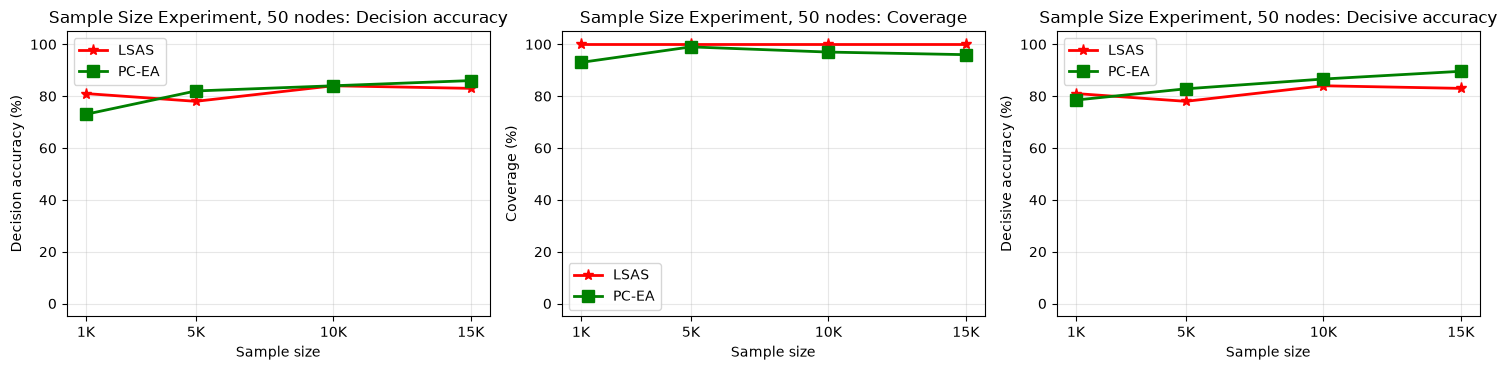

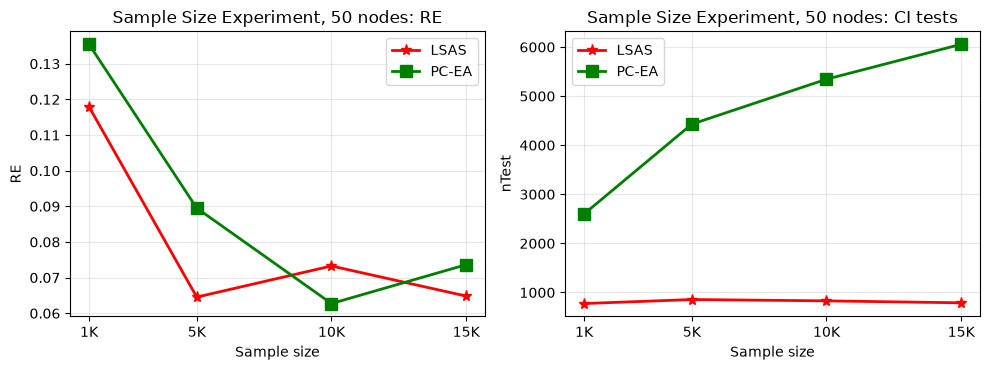

In [101]:
plot_experiment_metrics(
    decision_df=sample_size_base_decision_metrics,
    effect_df=sample_size_base_effect_effort,
    x_col="sample_size",
    x_label="Sample size",
    title_prefix=f"Sample Size Experiment, {BASE_N_OBS} nodes",
)


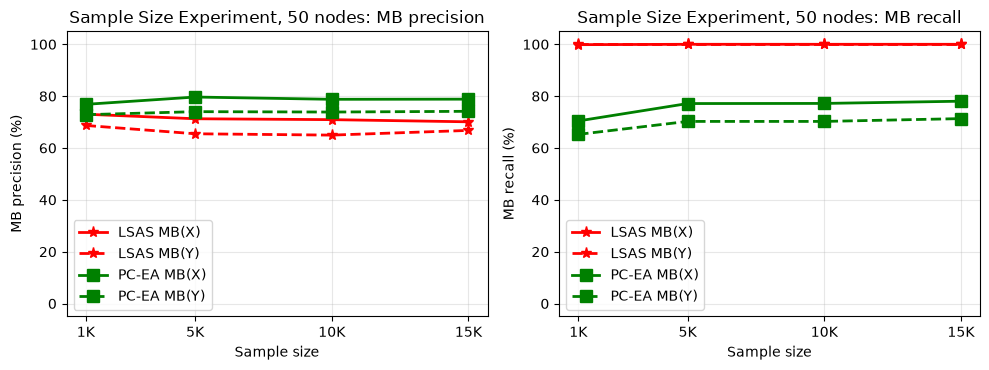

,sample_size,method,target,n_reps,mean_mb_precision,std_mb_precision,mean_mb_recall,std_mb_recall
0,1000,LSAS,X,100,0.730292,0.195936,0.998571,0.014286
1,1000,LSAS,Y,100,0.686930,0.201656,1.000000,0.000000
2,1000,PC-EA,X,100,0.768381,0.223376,0.704286,0.248894
3,1000,PC-EA,Y,100,0.728451,0.304308,0.652500,0.319813
4,5000,LSAS,X,100,0.712794,0.203055,1.000000,0.000000
5,5000,LSAS,Y,100,0.654848,0.193338,1.000000,0.000000
6,5000,PC-EA,X,100,0.796583,0.216425,0.771429,0.217429
7,5000,PC-EA,Y,100,0.740167,0.288375,0.702500,0.285070
8,10000,LSAS,X,100,0.709354,0.197177,1.000000,0.000000
9,10000,LSAS,Y,100,0.649688,0.185078,1.000000,0.000000


In [102]:
sample_size_base_mb_comparison, sample_size_base_mb_comparison_detail = compare_markov_blankets(
    sample_size_base_results,
    group_cols=["sample_size"],
)

plot_markov_blanket_metrics(
    sample_size_base_mb_comparison,
    x_col="sample_size",
    x_label="Sample size",
    title_prefix=f"Sample Size Experiment, {BASE_N_OBS} nodes",
)

sample_size_base_mb_comparison


### 250 nodes


In [103]:
BASE_N_OBS = 250
BASE_P = TARGET_AVG_DEGREE / (BASE_N_OBS + 1)

In [104]:
sample_size_base_results = run_structure_experiment(
    structure_name=f"Sample Size Experiment, n_obs = {BASE_N_OBS}...",
    sample_sizes=sample_sizes,
    n_reps=BASE_N_REPS,
    n_obs=BASE_N_OBS,
    p=BASE_P,
    beta=BASE_BETA,
    ci_method=BASE_CI_METHOD,
    n_force_x_parents=N_FORCE_X_PARENTS,
    n_force_y_parents=N_FORCE_Y_PARENTS,
    max_z_size=MAX_Z_SIZE,
)

sample_size_base_results["sample_experiment_n_obs"] = BASE_N_OBS
sample_size_base_results


Running Sample Size Experiment, n_obs = 250... with sample size 1000 for 100 reps...


Processing Sample Size Experiment, n_obs = 250...:   0%|          | 0/100 [00:00<?, ?it/s]

Processing Sample Size Experiment, n_obs = 250...: 100%|██████████| 100/100 [07:25<00:00,  4.45s/it]


Running Sample Size Experiment, n_obs = 250... with sample size 5000 for 100 reps...


Processing Sample Size Experiment, n_obs = 250...: 100%|██████████| 100/100 [07:12<00:00,  4.33s/it]


Running Sample Size Experiment, n_obs = 250... with sample size 10000 for 100 reps...


Processing Sample Size Experiment, n_obs = 250...: 100%|██████████| 100/100 [07:45<00:00,  4.65s/it]


Running Sample Size Experiment, n_obs = 250... with sample size 15000 for 100 reps...


Processing Sample Size Experiment, n_obs = 250...: 100%|██████████| 100/100 [08:04<00:00,  4.85s/it]


,method,structure,sample_size,rep,true_decision,decision,decision_correct,is_decisive,true_ce,estimated_ce,...,MB_y,actual_MB_x,actual_MB_y,x_degree,y_degree,avg_xy_degree,p,beta,noise_scale,sample_experiment_n_obs
0,PC-EA,"Sample Size Experiment, n_obs = 250...",1000,0,+,+,True,True,2.685172,2.947539,...,"[V146, V56, V77]","[V146, V174, V209, V225, V27, V61, outcome]","[V146, V174, V225, treatment]",4,4,4.0,0.011952,0,1.0,250
1,LSAS,"Sample Size Experiment, n_obs = 250...",1000,0,+,+,True,True,2.685172,3.323486,...,"[V37, V42, V58, V63, V68, V90, V101, V102, V10...","[V146, V174, V209, V225, V27, V61, outcome]","[V146, V174, V225, treatment]",4,4,4.0,0.011952,0,1.0,250
2,PC-EA,"Sample Size Experiment, n_obs = 250...",1000,1,0,0,True,True,0.000000,0.000000,...,"[V128, V212, V87]","[V172, V24, V53]","[V128, V212, V87]",3,3,3.0,0.011952,0,1.0,250
3,LSAS,"Sample Size Experiment, n_obs = 250...",1000,1,0,0,True,True,0.000000,0.000000,...,"[V17, V37, V87, V89, V92, V112, V117, V128, V1...","[V172, V24, V53]","[V128, V212, V87]",3,3,3.0,0.011952,0,1.0,250
4,PC-EA,"Sample Size Experiment, n_obs = 250...",1000,2,+,+,True,True,1.686463,1.752947,...,"[V101, V51]","[V101, V120, V150, V193, V51, V68, outcome]","[V101, V120, V51, treatment]",4,4,4.0,0.011952,0,1.0,250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,LSAS,"Sample Size Experiment, n_obs = 250...",15000,97,0,+,False,True,0.000000,0.068577,...,"[V19, V44, V59, V60, V75, V124, V125, V140, V1...","[V235, V43, V44]","[V140, V172, V75]",3,3,3.0,0.011952,0,1.0,250
796,PC-EA,"Sample Size Experiment, n_obs = 250...",15000,98,+,+,True,True,1.972765,1.967030,...,"[V17, V191, V195, V234]","[V115, V187, V191, V195, V217, V234, outcome]","[V191, V195, V234, treatment]",4,4,4.0,0.011952,0,1.0,250
797,LSAS,"Sample Size Experiment, n_obs = 250...",15000,98,+,+,True,True,1.972765,2.044685,...,"[V35, V49, V57, V61, V85, V89, V98, V129, V150...","[V115, V187, V191, V195, V217, V234, outcome]","[V191, V195, V234, treatment]",4,4,4.0,0.011952,0,1.0,250
798,PC-EA,"Sample Size Experiment, n_obs = 250...",15000,99,0,0,True,True,0.000000,0.000000,...,"[V186, V5, V89]","[V10, V150, V219]","[V186, V5, V89]",3,3,3.0,0.011952,0,1.0,250


In [105]:
sample_size_base_decision_metrics = (
    sample_size_base_results
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        decision_acc=("decision_correct", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
)

sample_size_base_decisive_metrics = (
    sample_size_base_results[sample_size_base_results["is_decisive"]]
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        decisive_acc=("decision_correct", "mean"),
        n_decisive=("decision", "size"),
    )
)

sample_size_base_decision_metrics = sample_size_base_decision_metrics.merge(
    sample_size_base_decisive_metrics,
    on=["method", "sample_size"],
    how="left",
)

sample_size_base_decision_metrics


,method,sample_size,decision_acc,coverage,n_reps,decisive_acc,n_decisive
0,LSAS,1000,0.77,1.0,100,0.77,100
1,LSAS,5000,0.77,1.0,100,0.77,100
2,LSAS,10000,0.80,1.0,100,0.80,100
3,LSAS,15000,0.78,1.0,100,0.78,100
4,PC-EA,1000,0.85,1.0,100,0.85,100
5,PC-EA,5000,0.83,1.0,100,0.83,100
6,PC-EA,10000,0.91,1.0,100,0.91,100
7,PC-EA,15000,0.91,1.0,100,0.91,100


In [106]:
sample_size_base_effect_effort = (
    sample_size_base_results
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

sample_size_base_effect_effort


,method,sample_size,mean_RE,std_RE,mean_nTest,std_nTest
0,LSAS,1000,0.125255,0.237127,48166.74,60406.790969
1,LSAS,5000,0.130389,0.305154,37460.51,32430.861166
2,LSAS,10000,0.103100,0.275441,37599.72,27812.446466
3,LSAS,15000,0.046327,0.089977,38976.42,33280.204181
4,PC-EA,1000,0.064281,0.153581,12288.69,5623.234805
5,PC-EA,5000,0.027946,0.041651,20293.36,12731.855824
6,PC-EA,10000,0.020826,0.031040,24370.39,17563.809264
7,PC-EA,15000,0.019332,0.033379,27755.25,21258.581967


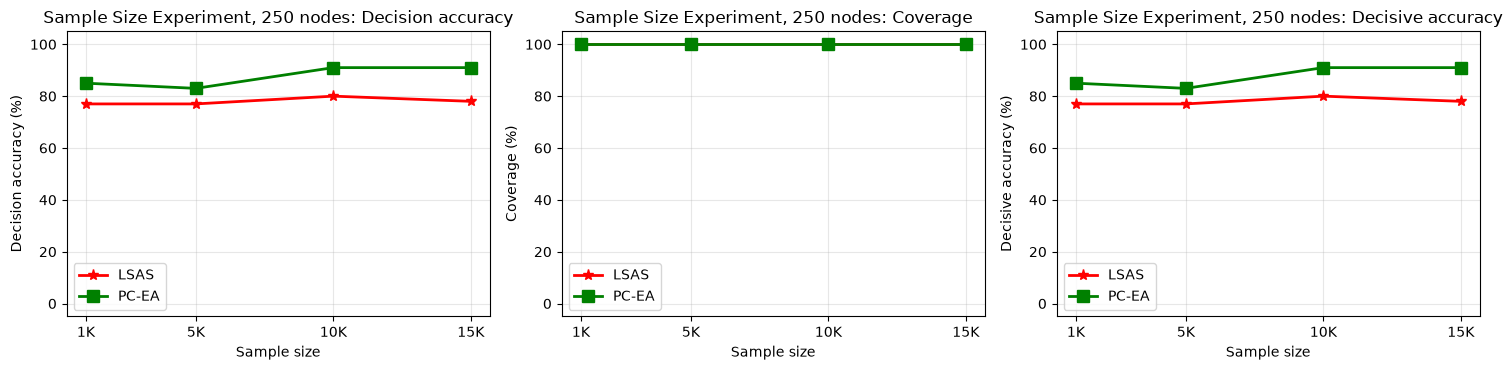

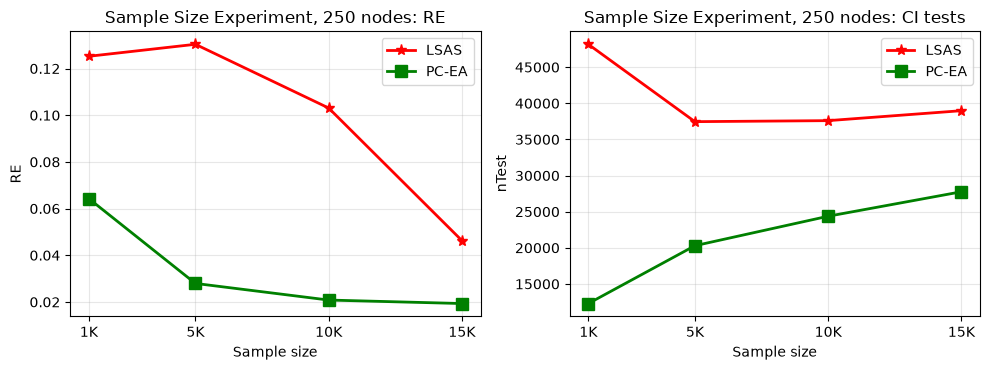

In [107]:
plot_experiment_metrics(
    decision_df=sample_size_base_decision_metrics,
    effect_df=sample_size_base_effect_effort,
    x_col="sample_size",
    x_label="Sample size",
    title_prefix=f"Sample Size Experiment, {BASE_N_OBS} nodes",
)


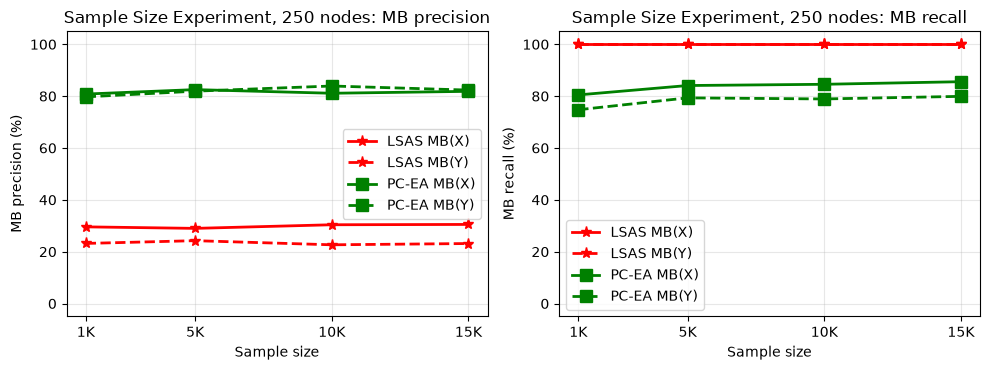

,sample_size,method,target,n_reps,mean_mb_precision,std_mb_precision,mean_mb_recall,std_mb_recall
0,1000,LSAS,X,100,0.295778,0.124170,1.000000,0.000000
1,1000,LSAS,Y,100,0.231852,0.071879,1.000000,0.000000
2,1000,PC-EA,X,100,0.808060,0.176576,0.804762,0.190656
3,1000,PC-EA,Y,100,0.797167,0.224196,0.747500,0.253055
4,5000,LSAS,X,100,0.289913,0.099691,1.000000,0.000000
5,5000,LSAS,Y,100,0.242480,0.079090,1.000000,0.000000
6,5000,PC-EA,X,100,0.825218,0.183525,0.840952,0.168966
7,5000,PC-EA,Y,100,0.819167,0.218894,0.793333,0.212370
8,10000,LSAS,X,100,0.303881,0.112207,1.000000,0.000000
9,10000,LSAS,Y,100,0.226562,0.065689,1.000000,0.000000


In [108]:
sample_size_base_mb_comparison, sample_size_base_mb_comparison_detail = compare_markov_blankets(
    sample_size_base_results,
    group_cols=["sample_size"],
)

plot_markov_blanket_metrics(
    sample_size_base_mb_comparison,
    x_col="sample_size",
    x_label="Sample size",
    title_prefix=f"Sample Size Experiment, {BASE_N_OBS} nodes",
)

sample_size_base_mb_comparison


### 400 nodes


In [109]:
BASE_N_OBS = 400
BASE_P = TARGET_AVG_DEGREE / (BASE_N_OBS + 1)

In [110]:
sample_size_alt_nobs_results = run_structure_experiment(
    structure_name=f"Sample Size Experiment, n_obs = {BASE_N_OBS}...",
    sample_sizes=sample_sizes,
    n_reps=BASE_N_REPS,
    n_obs=BASE_N_OBS,
    p=BASE_P,
    beta=BASE_BETA,
    ci_method=BASE_CI_METHOD,
    n_force_x_parents=N_FORCE_X_PARENTS,
    n_force_y_parents=N_FORCE_Y_PARENTS,
    max_z_size=MAX_Z_SIZE,
)

sample_size_alt_nobs_results["sample_experiment_n_obs"] = BASE_N_OBS
sample_size_alt_nobs_results


Running Sample Size Experiment, n_obs = 400... with sample size 1000 for 100 reps...


Processing Sample Size Experiment, n_obs = 400...: 100%|██████████| 100/100 [27:00<00:00, 16.21s/it]


Running Sample Size Experiment, n_obs = 400... with sample size 5000 for 100 reps...


Processing Sample Size Experiment, n_obs = 400...: 100%|██████████| 100/100 [28:59<00:00, 17.39s/it]


Running Sample Size Experiment, n_obs = 400... with sample size 10000 for 100 reps...


Processing Sample Size Experiment, n_obs = 400...: 100%|██████████| 100/100 [29:20<00:00, 17.61s/it]


Running Sample Size Experiment, n_obs = 400... with sample size 15000 for 100 reps...


Processing Sample Size Experiment, n_obs = 400...: 100%|██████████| 100/100 [27:30<00:00, 16.50s/it]


,method,structure,sample_size,rep,true_decision,decision,decision_correct,is_decisive,true_ce,estimated_ce,...,MB_y,actual_MB_x,actual_MB_y,x_degree,y_degree,avg_xy_degree,p,beta,noise_scale,sample_experiment_n_obs
0,PC-EA,"Sample Size Experiment, n_obs = 400...",1000,0,+,+,True,True,2.533424,2.748494,...,"[V115, V146, V222, V245]","[V217, V222, V245, V333, V334, V338, outcome]","[V222, V245, V334, treatment]",4,4,4.0,0.007481,0,1.0,400
1,LSAS,"Sample Size Experiment, n_obs = 400...",1000,0,+,+,True,True,2.533424,4.202999,...,"[V3, V25, V36, V61, V103, V142, V169, V222, V2...","[V217, V222, V245, V333, V334, V338, outcome]","[V222, V245, V334, treatment]",4,4,4.0,0.007481,0,1.0,400
2,PC-EA,"Sample Size Experiment, n_obs = 400...",1000,1,0,0,True,True,0.000000,0.000000,...,"[V212, V217, V38]","[V2, V239, V94]","[V212, V217, V38]",3,3,3.0,0.007481,0,1.0,400
3,LSAS,"Sample Size Experiment, n_obs = 400...",1000,1,0,0,True,True,0.000000,0.000000,...,"[V3, V16, V17, V37, V38, V74, V87, V114, V163,...","[V2, V239, V94]","[V212, V217, V38]",3,3,3.0,0.007481,0,1.0,400
4,PC-EA,"Sample Size Experiment, n_obs = 400...",1000,2,+,+,True,True,1.840475,1.847937,...,"[V19, V27, V363, V92]","[V19, V27, V363, V45, V50, V63, outcome]","[V19, V27, V363, treatment]",4,4,4.0,0.007481,0,1.0,400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,LSAS,"Sample Size Experiment, n_obs = 400...",15000,97,0,+,False,True,0.000000,0.439140,...,"[V26, V45, V47, V51, V67, V94, V101, V153, V16...","[V209, V351, V59]","[V312, V47, V94]",3,3,3.0,0.007481,0,1.0,400
796,PC-EA,"Sample Size Experiment, n_obs = 400...",15000,98,+,+,True,True,2.141848,2.148128,...,"[V10, V135, V399]","[V10, V135, V147, V162, V322, V399, outcome]","[V10, V135, V399, treatment]",4,4,4.0,0.007481,0,1.0,400
797,LSAS,"Sample Size Experiment, n_obs = 400...",15000,98,+,+,True,True,2.141848,2.205271,...,"[V10, V40, V61, V80, V135, V147, V192, V220, V...","[V10, V135, V147, V162, V322, V399, outcome]","[V10, V135, V399, treatment]",4,4,4.0,0.007481,0,1.0,400
798,PC-EA,"Sample Size Experiment, n_obs = 400...",15000,99,0,0,True,True,0.000000,0.000000,...,"[V113, V156, V226, V229, V299, V380, V92]","[V215, V83, V88]","[V156, V226, V299]",3,3,3.0,0.007481,0,1.0,400


In [111]:
sample_size_alt_nobs_decision_metrics = (
    sample_size_alt_nobs_results
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        decision_acc=("decision_correct", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
)

sample_size_alt_nobs_decisive_metrics = (
    sample_size_alt_nobs_results[sample_size_alt_nobs_results["is_decisive"]]
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        decisive_acc=("decision_correct", "mean"),
        n_decisive=("decision", "size"),
    )
)

sample_size_alt_nobs_decision_metrics = sample_size_alt_nobs_decision_metrics.merge(
    sample_size_alt_nobs_decisive_metrics,
    on=["method", "sample_size"],
    how="left",
)

sample_size_alt_nobs_decision_metrics


,method,sample_size,decision_acc,coverage,n_reps,decisive_acc,n_decisive
0,LSAS,1000,0.84,1.00,100,0.840000,100
1,LSAS,5000,0.80,1.00,100,0.800000,100
2,LSAS,10000,0.80,1.00,100,0.800000,100
3,LSAS,15000,0.78,1.00,100,0.780000,100
4,PC-EA,1000,0.94,1.00,100,0.940000,100
5,PC-EA,5000,0.90,0.99,100,0.909091,99
6,PC-EA,10000,0.94,1.00,100,0.940000,100
7,PC-EA,15000,0.92,1.00,100,0.920000,100


In [112]:
sample_size_alt_nobs_effect_effort = (
    sample_size_alt_nobs_results
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

sample_size_alt_nobs_effect_effort


,method,sample_size,mean_RE,std_RE,mean_nTest,std_nTest
0,LSAS,1000,0.105107,0.263237,190329.58,171587.153057
1,LSAS,5000,0.063536,0.129168,195421.49,150417.157152
2,LSAS,10000,0.101036,0.310501,190844.92,156683.286274
3,LSAS,15000,0.078551,0.185781,167393.49,130449.923332
4,PC-EA,1000,0.043228,0.110328,17411.89,8355.389096
5,PC-EA,5000,0.011922,0.019191,26594.26,17120.139226
6,PC-EA,10000,0.031139,0.141159,31439.66,23344.277623
7,PC-EA,15000,0.041765,0.162539,35063.62,28954.034178


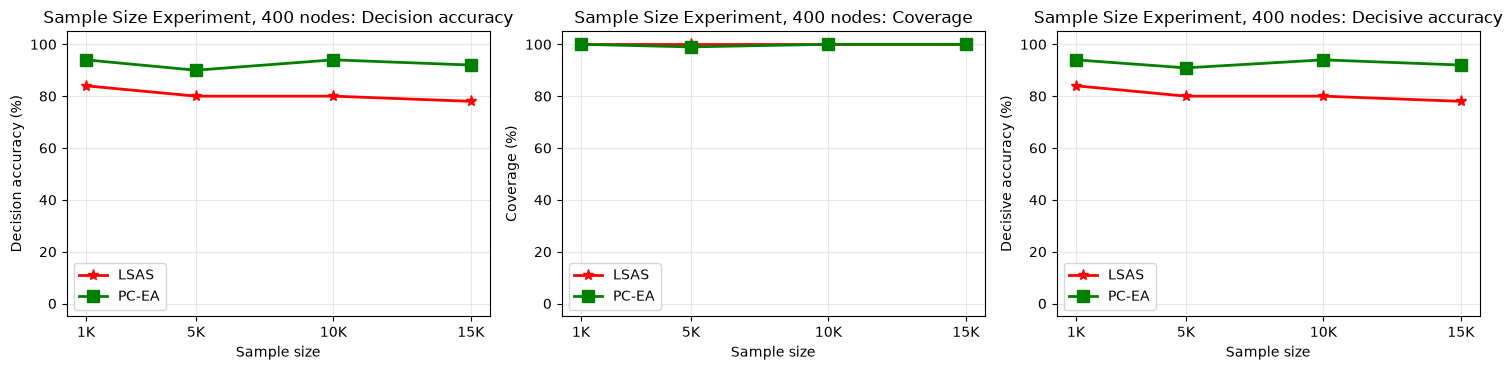

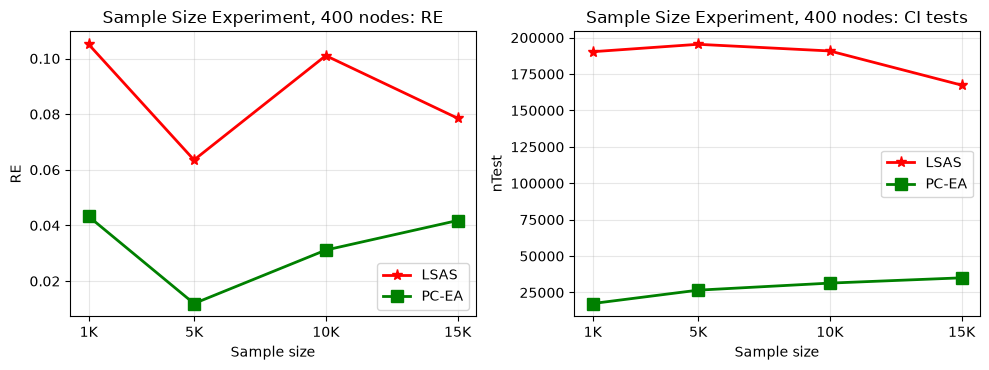

In [113]:
plot_experiment_metrics(
    decision_df=sample_size_alt_nobs_decision_metrics,
    effect_df=sample_size_alt_nobs_effect_effort,
    x_col="sample_size",
    x_label="Sample size",
    title_prefix=f"Sample Size Experiment, {BASE_N_OBS} nodes",
)


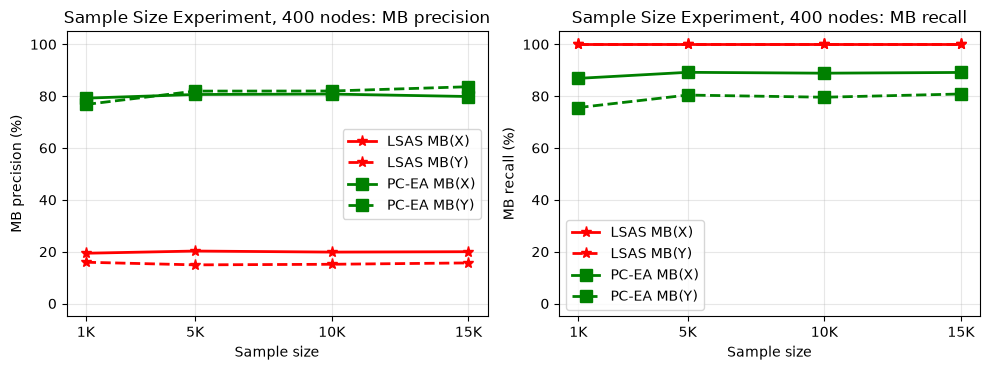

,sample_size,method,target,n_reps,mean_mb_precision,std_mb_precision,mean_mb_recall,std_mb_recall
0,1000,LSAS,X,100,0.193986,0.079851,1.000000,0.000000
1,1000,LSAS,Y,100,0.159313,0.048637,1.000000,0.000000
2,1000,PC-EA,X,100,0.792210,0.184763,0.868571,0.156422
3,1000,PC-EA,Y,100,0.767833,0.232975,0.755833,0.224813
4,5000,LSAS,X,100,0.202501,0.078070,1.000000,0.000000
5,5000,LSAS,Y,100,0.149175,0.035176,1.000000,0.000000
6,5000,PC-EA,X,100,0.806393,0.179712,0.891905,0.130516
7,5000,PC-EA,Y,100,0.819452,0.209171,0.804167,0.187792
8,10000,LSAS,X,100,0.198426,0.081135,1.000000,0.000000
9,10000,LSAS,Y,100,0.151433,0.033877,1.000000,0.000000


In [114]:
sample_size_alt_nobs_mb_comparison, sample_size_alt_nobs_mb_comparison_detail = compare_markov_blankets(
    sample_size_alt_nobs_results,
    group_cols=["sample_size"],
)

plot_markov_blanket_metrics(
    sample_size_alt_nobs_mb_comparison,
    x_col="sample_size",
    x_label="Sample size",
    title_prefix=f"Sample Size Experiment, {BASE_N_OBS} nodes",
)

sample_size_alt_nobs_mb_comparison


## Graph Size Experiment


In [145]:
graph_size_results_list = []

for graph_size in graph_sizes:
    results_one_graph_size = run_structure_experiment(
        structure_name=f"Graph size experiment, n_obs={graph_size}",
        sample_sizes=[BASE_SAMPLE_SIZE],
        n_reps=BASE_N_REPS,
        n_obs=graph_size,
        p=p_for_size(graph_size, TARGET_AVG_DEGREE),
        beta=BASE_BETA,
        ci_method=BASE_CI_METHOD,
        n_force_x_parents=N_FORCE_X_PARENTS,
        n_force_y_parents=N_FORCE_Y_PARENTS,
        max_z_size=MAX_Z_SIZE
        )
    results_one_graph_size["graph_size"] = graph_size
    graph_size_results_list.append(results_one_graph_size)

graph_size_results = pd.concat(graph_size_results_list, ignore_index=True)
graph_size_results


Running Graph size experiment, n_obs=100 with sample size 5000 for 100 reps...


Processing Graph size experiment, n_obs=100: 100%|██████████| 100/100 [01:20<00:00,  1.24it/s]


Running Graph size experiment, n_obs=200 with sample size 5000 for 100 reps...


Processing Graph size experiment, n_obs=200: 100%|██████████| 100/100 [04:23<00:00,  2.64s/it]


Running Graph size experiment, n_obs=300 with sample size 5000 for 100 reps...


Processing Graph size experiment, n_obs=300: 100%|██████████| 100/100 [11:31<00:00,  6.91s/it]


Running Graph size experiment, n_obs=400 with sample size 5000 for 100 reps...


Processing Graph size experiment, n_obs=400: 100%|██████████| 100/100 [29:18<00:00, 17.58s/it]


,method,structure,sample_size,rep,true_decision,decision,decision_correct,is_decisive,true_ce,estimated_ce,...,MB_y,actual_MB_x,actual_MB_y,x_degree,y_degree,avg_xy_degree,p,beta,noise_scale,graph_size
0,PC-EA,"Graph size experiment, n_obs=100",5000,0,+,+,True,True,1.981064,1.980462,...,"[V37, V52, V59]","[V1, V37, V50, V52, V59, V96, outcome]","[V37, V52, V59, treatment]",4,4,4.0,0.029703,0,1.0,100
1,LSAS,"Graph size experiment, n_obs=100",5000,0,+,+,True,True,1.981064,1.981094,...,"[V11, V13, V37, V52, V56, V59, V78, V96, treat...","[V1, V37, V50, V52, V59, V96, outcome]","[V37, V52, V59, treatment]",4,4,4.0,0.029703,0,1.0,100
2,PC-EA,"Graph size experiment, n_obs=100",5000,1,0,0,True,True,0.000000,0.000000,...,"[V4, V74, V94]","[V36, V78, V83]","[V4, V74, V94]",3,3,3.0,0.029703,0,1.0,100
3,LSAS,"Graph size experiment, n_obs=100",5000,1,0,0,True,True,0.000000,0.000000,...,"[V2, V4, V49, V63, V74, V75, V94]","[V36, V78, V83]","[V4, V74, V94]",3,3,3.0,0.029703,0,1.0,100
4,PC-EA,"Graph size experiment, n_obs=100",5000,2,+,+,True,True,1.469639,1.885753,...,"[V0, V30, V37]","[V15, V21, V37, V68, V88, V91, outcome]","[V37, V68, V91, treatment]",4,4,4.0,0.029703,0,1.0,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,LSAS,"Graph size experiment, n_obs=400",5000,97,0,+,False,True,0.000000,0.648198,...,"[V47, V79, V82, V94, V100, V132, V148, V153, V...","[V209, V351, V59]","[V312, V47, V94]",3,3,3.0,0.007481,0,1.0,400
796,PC-EA,"Graph size experiment, n_obs=400",5000,98,+,+,True,True,2.141848,2.133664,...,"[V10, V135, V399]","[V10, V135, V147, V162, V322, V399, outcome]","[V10, V135, V399, treatment]",4,4,4.0,0.007481,0,1.0,400
797,LSAS,"Graph size experiment, n_obs=400",5000,98,+,+,True,True,2.141848,2.128170,...,"[V10, V19, V48, V68, V90, V135, V153, V205, V2...","[V10, V135, V147, V162, V322, V399, outcome]","[V10, V135, V399, treatment]",4,4,4.0,0.007481,0,1.0,400
798,PC-EA,"Graph size experiment, n_obs=400",5000,99,0,0,True,True,0.000000,0.000000,...,"[V156, V226, V251, V286, V299, V37, V386]","[V215, V83, V88]","[V156, V226, V299]",3,3,3.0,0.007481,0,1.0,400


In [146]:
graph_size_decision_metrics = (
    graph_size_results
    .groupby(["method", "graph_size"], as_index=False)
    .agg(
        decision_acc=("decision_correct", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
)

graph_size_decisive_metrics = (
    graph_size_results[graph_size_results["is_decisive"]]
    .groupby(["graph_size", "method"], as_index=False)
    .agg(
        decisive_acc=("decision_correct", "mean"),
        n_decisive=("decision", "size"),
    )
)

graph_size_decision_metrics = graph_size_decision_metrics.merge(
    graph_size_decisive_metrics,
    on=["graph_size", "method"],
    how="left",
)

graph_size_decision_metrics["n_decisive"] = graph_size_decision_metrics["n_decisive"].fillna(0).astype(int)

graph_size_decision_metrics


,method,graph_size,decision_acc,coverage,n_reps,decisive_acc,n_decisive
0,LSAS,100,0.79,1.00,100,0.790000,100
1,LSAS,200,0.77,1.00,100,0.770000,100
2,LSAS,300,0.77,1.00,100,0.770000,100
3,LSAS,400,0.80,1.00,100,0.800000,100
4,PC-EA,100,0.81,0.96,100,0.843750,96
5,PC-EA,200,0.92,1.00,100,0.920000,100
6,PC-EA,300,0.87,1.00,100,0.870000,100
7,PC-EA,400,0.90,0.99,100,0.909091,99


In [147]:
graph_size_effect_effort = (
    graph_size_results
    .groupby(["method", "graph_size"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

graph_size_effect_effort


,method,graph_size,mean_RE,std_RE,mean_nTest,std_nTest
0,LSAS,100,0.177935,0.393547,2968.97,3321.379382
1,LSAS,200,0.080005,0.106004,19281.45,16489.950146
2,LSAS,300,0.084389,0.157577,68910.00,73630.852255
3,LSAS,400,0.063536,0.129168,195421.49,150417.157152
4,PC-EA,100,0.099910,0.264283,7970.60,5024.048914
5,PC-EA,200,0.034010,0.048389,15889.64,10397.204554
6,PC-EA,300,0.018856,0.028473,21209.63,16869.769354
7,PC-EA,400,0.011922,0.019191,26594.26,17120.139226


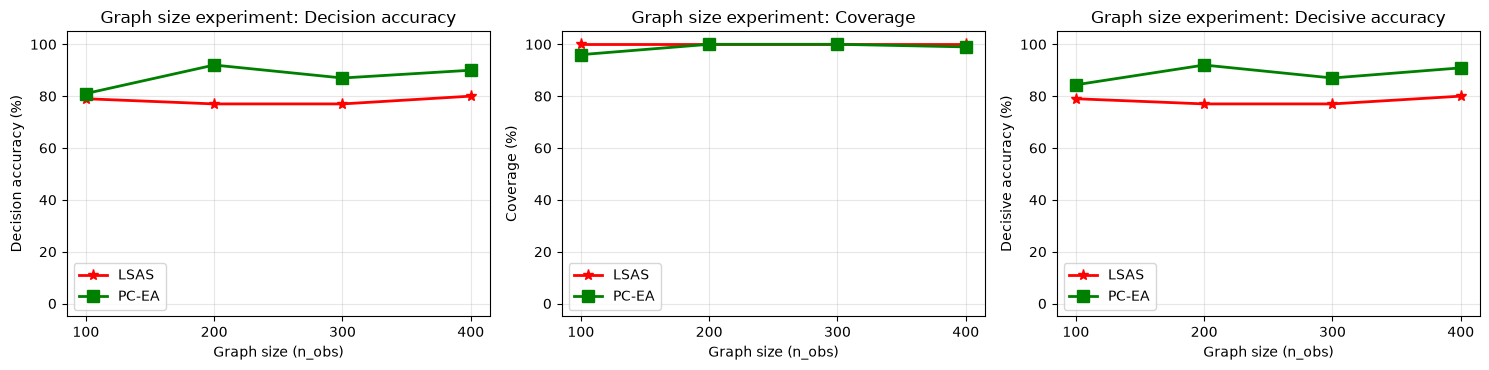

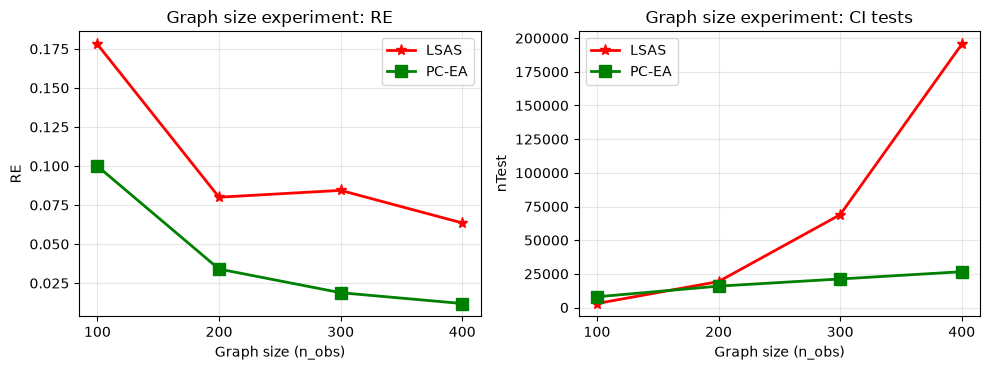

In [148]:
plot_experiment_metrics(
    decision_df=graph_size_decision_metrics,
    effect_df=graph_size_effect_effort,
    x_col="graph_size",
    x_label="Graph size (n_obs)",
    title_prefix="Graph size experiment",
)


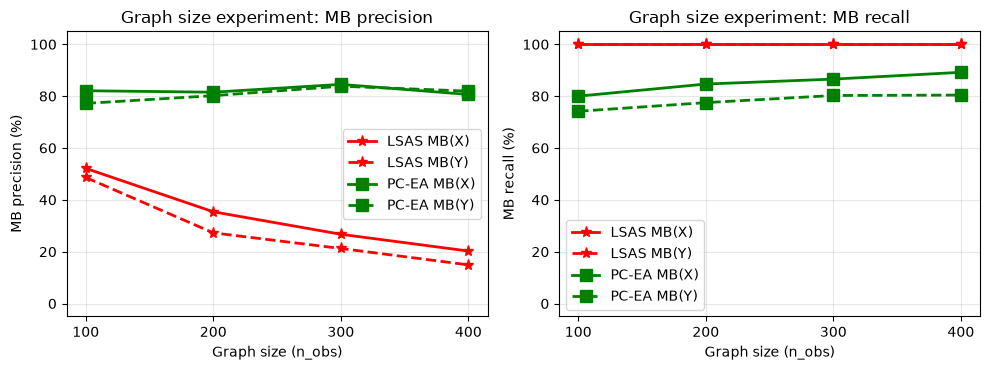

,graph_size,method,target,n_reps,mean_mb_precision,std_mb_precision,mean_mb_recall,std_mb_recall
0,100,LSAS,X,100,0.521364,0.185639,1.000000,0.000000
1,100,LSAS,Y,100,0.486325,0.166771,1.000000,0.000000
2,100,PC-EA,X,100,0.820877,0.216637,0.800000,0.209161
3,100,PC-EA,Y,100,0.772024,0.255519,0.741667,0.241436
4,200,LSAS,X,100,0.353956,0.126121,1.000000,0.000000
5,200,LSAS,Y,100,0.272723,0.085058,1.000000,0.000000
6,200,PC-EA,X,100,0.815187,0.185379,0.846667,0.173429
7,200,PC-EA,Y,100,0.801952,0.239395,0.775000,0.235851
8,300,LSAS,X,100,0.267192,0.107646,1.000000,0.000000
9,300,LSAS,Y,100,0.212349,0.071153,1.000000,0.000000


In [149]:
graph_size_mb_comparison, graph_size_mb_comparison_detail = compare_markov_blankets(
    graph_size_results,
    group_cols=["graph_size"],
)

plot_markov_blanket_metrics(
    graph_size_mb_comparison,
    x_col="graph_size",
    x_label="Graph size (n_obs)",
    title_prefix="Graph size experiment",
)

graph_size_mb_comparison


## Average Degree Experiment


### 50 Nodes

In [120]:
BASE_N_OBS = 50

In [121]:
avg_degree_results_list = []

for avg_degree in avg_degrees:
    results_one_avg_degree = run_structure_experiment(
        structure_name=f"Average degree experiment, avg_degree={avg_degree}",
        sample_sizes=[BASE_SAMPLE_SIZE],
        n_reps=BASE_N_REPS,
        n_obs=BASE_N_OBS,
        p=p_for_size(BASE_N_OBS, avg_degree=avg_degree),
        beta=BASE_BETA,
        ci_method=BASE_CI_METHOD,
        n_force_x_parents=avg_degree,
        n_force_y_parents=avg_degree,
        max_z_size=MAX_Z_SIZE
        )
    results_one_avg_degree["avg_degree"] = avg_degree
    avg_degree_results_list.append(results_one_avg_degree)

avg_degree_results = pd.concat(avg_degree_results_list, ignore_index=True)
avg_degree_results


Running Average degree experiment, avg_degree=3 with sample size 5000 for 100 reps...


Processing Average degree experiment, avg_degree=3: 100%|██████████| 100/100 [00:29<00:00,  3.43it/s]


Running Average degree experiment, avg_degree=4 with sample size 5000 for 100 reps...


Processing Average degree experiment, avg_degree=4: 100%|██████████| 100/100 [00:53<00:00,  1.86it/s]


Running Average degree experiment, avg_degree=5 with sample size 5000 for 100 reps...


Processing Average degree experiment, avg_degree=5: 100%|██████████| 100/100 [01:08<00:00,  1.46it/s]


Running Average degree experiment, avg_degree=6 with sample size 5000 for 100 reps...


Processing Average degree experiment, avg_degree=6: 100%|██████████| 100/100 [01:13<00:00,  1.36it/s]


,method,structure,sample_size,rep,true_decision,decision,decision_correct,is_decisive,true_ce,estimated_ce,...,MB_y,actual_MB_x,actual_MB_y,x_degree,y_degree,avg_xy_degree,p,beta,noise_scale,avg_degree
0,PC-EA,"Average degree experiment, avg_degree=3",5000,0,+,+,True,True,2.103282,1.974744,...,"[V14, V20, V41]","[V14, V20, V25, V26, V3, V6, outcome]","[V14, V20, V3, treatment]",4,4,4.0,0.058824,0,1.0,3
1,LSAS,"Average degree experiment, avg_degree=3",5000,0,+,+,True,True,2.103282,2.122766,...,"[V3, V10, V11, V14, V20, V48, treatment]","[V14, V20, V25, V26, V3, V6, outcome]","[V14, V20, V3, treatment]",4,4,4.0,0.058824,0,1.0,3
2,PC-EA,"Average degree experiment, avg_degree=3",5000,1,0,0,True,True,0.000000,0.000000,...,"[V14, V22, V33]","[V28, V29, V40]","[V14, V22, V33]",3,3,3.0,0.058824,0,1.0,3
3,LSAS,"Average degree experiment, avg_degree=3",5000,1,0,0,True,True,0.000000,0.000000,...,"[V1, V5, V11, V14, V21, V22, V30, V33, V40]","[V28, V29, V40]","[V14, V22, V33]",3,3,3.0,0.058824,0,1.0,3
4,PC-EA,"Average degree experiment, avg_degree=3",5000,2,+,+,True,True,1.299327,1.352523,...,"[V13, V19, V25, V34, V42]","[V19, V25, V30, V34, V39, V5, outcome]","[V19, V34, V5, treatment]",4,4,4.0,0.058824,0,1.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,LSAS,"Average degree experiment, avg_degree=6",5000,97,0,+,False,True,0.000000,1.144890,...,"[V4, V7, V24, V25, V28, V30, V45, V49]","[V10, V21, V29, V43, V47, V8]","[V25, V28, V30, V4, V45, V49]",6,6,6.0,0.117647,0,1.0,6
796,PC-EA,"Average degree experiment, avg_degree=6",5000,98,+,?,False,False,2.206331,NaN,...,"[V10, V8, V9]","[V0, V11, V13, V17, V20, V22, V31, V42, V47, V...","[V11, V13, V17, V22, V47, V8, treatment]",7,7,7.0,0.117647,0,1.0,6
797,LSAS,"Average degree experiment, avg_degree=6",5000,98,+,+,True,True,2.206331,3.860566,...,"[V8, V11, V13, V17, V22, V47, treatment]","[V0, V11, V13, V17, V20, V22, V31, V42, V47, V...","[V11, V13, V17, V22, V47, V8, treatment]",7,7,7.0,0.117647,0,1.0,6
798,PC-EA,"Average degree experiment, avg_degree=6",5000,99,0,+,False,True,0.000000,0.552765,...,"[V39, V43, V8]","[V11, V13, V16, V3, V35, V38]","[V20, V26, V43, V47, V48, V8]",6,6,6.0,0.117647,0,1.0,6


In [122]:
avg_degree_decision_metrics = (
    avg_degree_results
    .groupby(["method", "avg_degree"], as_index=False)
    .agg(
        decision_acc=("decision_correct", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
)

avg_degree_decisive_metrics = (
    avg_degree_results[avg_degree_results["is_decisive"]]
    .groupby(["method", "avg_degree"], as_index=False)
    .agg(
        decisive_acc=("decision_correct", "mean"),
        n_decisive=("decision", "size"),
    )
)

avg_degree_decision_metrics = avg_degree_decision_metrics.merge(
    avg_degree_decisive_metrics,
    on=["method", "avg_degree"],
    how="left",
)

avg_degree_decision_metrics


,method,avg_degree,decision_acc,coverage,n_reps,decisive_acc,n_decisive
0,LSAS,3,0.78,1.00,100,0.780000,100
1,LSAS,4,0.55,1.00,100,0.550000,100
2,LSAS,5,0.50,1.00,100,0.500000,100
3,LSAS,6,0.50,1.00,100,0.500000,100
4,PC-EA,3,0.82,0.99,100,0.828283,99
5,PC-EA,4,0.50,0.93,100,0.537634,93
6,PC-EA,5,0.35,0.77,100,0.454545,77
7,PC-EA,6,0.32,0.80,100,0.400000,80


In [123]:
avg_degree_effect_effort = (
    avg_degree_results
    .groupby(["method", "avg_degree"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

avg_degree_effect_effort


,method,avg_degree,mean_RE,std_RE,mean_nTest,std_nTest
0,LSAS,3,0.064538,0.095390,856.05,922.615237
1,LSAS,4,0.495713,0.586969,1301.81,943.895771
2,LSAS,5,0.569982,0.880701,2394.10,2420.857372
3,LSAS,6,1.043609,3.245443,3467.83,2452.219127
4,PC-EA,3,0.089488,0.175970,4428.62,2571.055892
5,PC-EA,4,0.262057,0.283115,8977.89,2608.506581
6,PC-EA,5,0.347896,0.351266,10715.83,2159.660617
7,PC-EA,6,0.443446,0.503145,10460.81,1612.088148


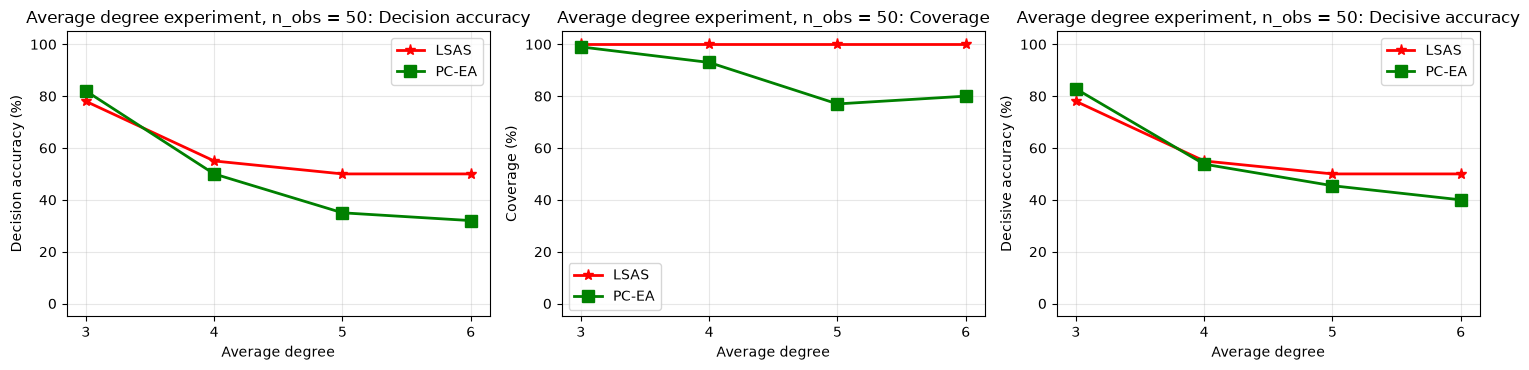

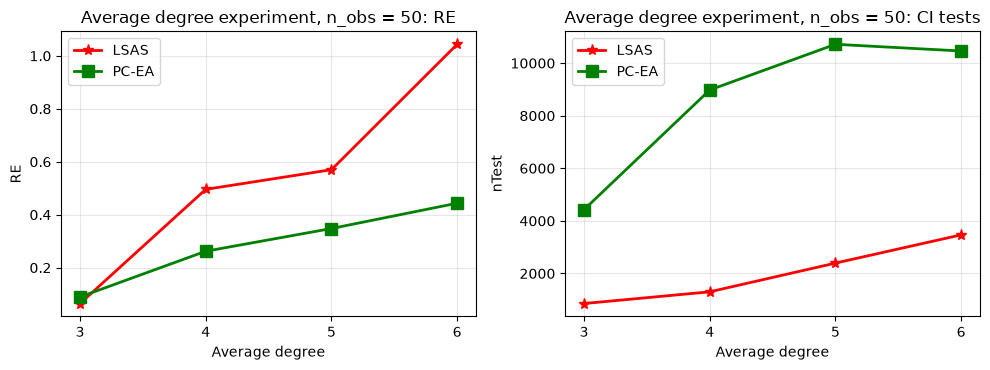

In [124]:
plot_experiment_metrics(
    decision_df=avg_degree_decision_metrics,
    effect_df=avg_degree_effect_effort,
    x_col="avg_degree",
    x_label="Average degree",
    title_prefix=f"Average degree experiment, n_obs = {BASE_N_OBS}",
)


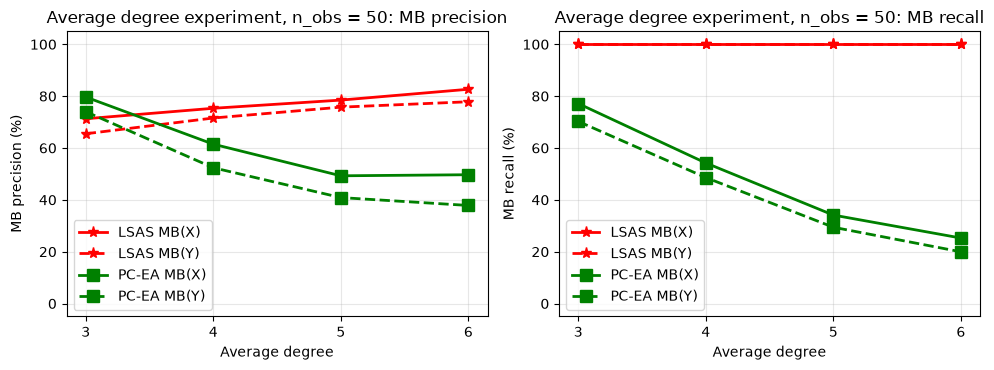

,avg_degree,method,target,n_reps,mean_mb_precision,std_mb_precision,mean_mb_recall,std_mb_recall
0,3,LSAS,X,100,0.712794,0.203055,1.000000,0.000000
1,3,LSAS,Y,100,0.654848,0.193338,1.000000,0.000000
2,3,PC-EA,X,100,0.796583,0.216425,0.771429,0.217429
3,3,PC-EA,Y,100,0.740167,0.288375,0.702500,0.285070
4,4,LSAS,X,100,0.753166,0.160543,1.000000,0.000000
5,4,LSAS,Y,100,0.715627,0.170169,1.000000,0.000000
6,4,PC-EA,X,100,0.614702,0.232394,0.542222,0.241112
7,4,PC-EA,Y,100,0.523833,0.281024,0.486000,0.297810
8,5,LSAS,X,100,0.784753,0.141165,1.000000,0.000000
9,5,LSAS,Y,100,0.757540,0.166514,1.000000,0.000000


In [125]:
avg_degree_mb_comparison, avg_degree_mb_comparison_detail = compare_markov_blankets(
    avg_degree_results,
    group_cols=["avg_degree"],
)

plot_markov_blanket_metrics(
    avg_degree_mb_comparison,
    x_col="avg_degree",
    x_label="Average degree",
    title_prefix=f"Average degree experiment, n_obs = {BASE_N_OBS}",
)

avg_degree_mb_comparison


### 250 Nodes

In [126]:
BASE_N_OBS = 250

In [127]:
avg_degree_results_list = []

for avg_degree in avg_degrees:
    results_one_avg_degree = run_structure_experiment(
        structure_name=f"Average degree experiment, avg_degree={avg_degree}",
        sample_sizes=[BASE_SAMPLE_SIZE],
        n_reps=BASE_N_REPS,
        n_obs=BASE_N_OBS,
        p=p_for_size(BASE_N_OBS, avg_degree=avg_degree),
        beta=BASE_BETA,
        ci_method=BASE_CI_METHOD,
        n_force_x_parents=avg_degree,
        n_force_y_parents=avg_degree,
        max_z_size=MAX_Z_SIZE
        )
    results_one_avg_degree["avg_degree"] = avg_degree
    avg_degree_results_list.append(results_one_avg_degree)

avg_degree_results = pd.concat(avg_degree_results_list, ignore_index=True)
avg_degree_results


Running Average degree experiment, avg_degree=3 with sample size 5000 for 100 reps...


Processing Average degree experiment, avg_degree=3: 100%|██████████| 100/100 [07:10<00:00,  4.30s/it]


Running Average degree experiment, avg_degree=4 with sample size 5000 for 100 reps...


Processing Average degree experiment, avg_degree=4: 100%|██████████| 100/100 [11:18<00:00,  6.79s/it]


Running Average degree experiment, avg_degree=5 with sample size 5000 for 100 reps...


Processing Average degree experiment, avg_degree=5: 100%|██████████| 100/100 [15:19<00:00,  9.19s/it]


Running Average degree experiment, avg_degree=6 with sample size 5000 for 100 reps...


Processing Average degree experiment, avg_degree=6: 100%|██████████| 100/100 [15:53<00:00,  9.53s/it]


,method,structure,sample_size,rep,true_decision,decision,decision_correct,is_decisive,true_ce,estimated_ce,...,MB_y,actual_MB_x,actual_MB_y,x_degree,y_degree,avg_xy_degree,p,beta,noise_scale,avg_degree
0,PC-EA,"Average degree experiment, avg_degree=3",5000,0,+,+,True,True,2.685172,3.002933,...,"[V146, V174, V2, V231, V56]","[V146, V174, V209, V225, V27, V61, outcome]","[V146, V174, V225, treatment]",4,4,4.0,0.011952,0,1.0,3
1,LSAS,"Average degree experiment, avg_degree=3",5000,0,+,+,True,True,2.685172,3.122125,...,"[V2, V28, V30, V146, V163, V173, V174, V186, V...","[V146, V174, V209, V225, V27, V61, outcome]","[V146, V174, V225, treatment]",4,4,4.0,0.011952,0,1.0,3
2,PC-EA,"Average degree experiment, avg_degree=3",5000,1,0,+,False,True,0.000000,0.658653,...,"[V128, V212, V87]","[V172, V24, V53]","[V128, V212, V87]",3,3,3.0,0.011952,0,1.0,3
3,LSAS,"Average degree experiment, avg_degree=3",5000,1,0,+,False,True,0.000000,0.656166,...,"[V50, V51, V56, V67, V77, V87, V113, V128, V16...","[V172, V24, V53]","[V128, V212, V87]",3,3,3.0,0.011952,0,1.0,3
4,PC-EA,"Average degree experiment, avg_degree=3",5000,2,+,+,True,True,1.686463,1.681564,...,"[V101, V120, V51]","[V101, V120, V150, V193, V51, V68, outcome]","[V101, V120, V51, treatment]",4,4,4.0,0.011952,0,1.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,LSAS,"Average degree experiment, avg_degree=6",5000,97,0,+,False,True,0.000000,1.555797,...,"[V19, V38, V50, V79, V80, V98, V124, V130, V14...","[V121, V15, V181, V227, V53, V80]","[V130, V19, V195, V207, V217, V235]",6,6,6.0,0.023904,0,1.0,6
796,PC-EA,"Average degree experiment, avg_degree=6",5000,98,+,?,False,False,2.828388,NaN,...,[V48],"[V109, V150, V180, V197, V244, V26, V34, V44, ...","[V109, V197, V244, V26, V71, V91, treatment]",7,7,7.0,0.023904,0,1.0,6
797,LSAS,"Average degree experiment, avg_degree=6",5000,98,+,+,True,True,2.828388,2.952708,...,"[V20, V26, V40, V48, V66, V71, V72, V86, V87, ...","[V109, V150, V180, V197, V244, V26, V34, V44, ...","[V109, V197, V244, V26, V71, V91, treatment]",7,7,7.0,0.023904,0,1.0,6
798,PC-EA,"Average degree experiment, avg_degree=6",5000,99,0,+,False,True,0.000000,0.299641,...,"[V119, V151, V153, V166, V29, V52]","[V122, V141, V144, V196, V42, V93]","[V119, V151, V166, V245, V29, V52]",6,6,6.0,0.023904,0,1.0,6


In [128]:
avg_degree_decision_metrics = (
    avg_degree_results
    .groupby(["method", "avg_degree"], as_index=False)
    .agg(
        decision_acc=("decision_correct", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
)

avg_degree_decisive_metrics = (
    avg_degree_results[avg_degree_results["is_decisive"]]
    .groupby(["method", "avg_degree"], as_index=False)
    .agg(
        decisive_acc=("decision_correct", "mean"),
        n_decisive=("decision", "size"),
    )
)

avg_degree_decision_metrics = avg_degree_decision_metrics.merge(
    avg_degree_decisive_metrics,
    on=["method", "avg_degree"],
    how="left",
)

avg_degree_decision_metrics


,method,avg_degree,decision_acc,coverage,n_reps,decisive_acc,n_decisive
0,LSAS,3,0.77,1.00,100,0.770000,100
1,LSAS,4,0.57,1.00,100,0.570000,100
2,LSAS,5,0.50,1.00,100,0.500000,100
3,LSAS,6,0.50,1.00,100,0.500000,100
4,PC-EA,3,0.83,1.00,100,0.830000,100
5,PC-EA,4,0.66,0.98,100,0.673469,98
6,PC-EA,5,0.45,0.92,100,0.489130,92
7,PC-EA,6,0.38,0.86,100,0.441860,86


In [129]:
avg_degree_effect_effort = (
    avg_degree_results
    .groupby(["method", "avg_degree"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

avg_degree_effect_effort


,method,avg_degree,mean_RE,std_RE,mean_nTest,std_nTest
0,LSAS,3,0.130389,0.305154,37460.51,32430.861166
1,LSAS,4,0.246752,0.308753,47774.23,35765.276943
2,LSAS,5,0.431679,0.441169,58566.76,46737.024162
3,LSAS,6,0.777615,1.074461,65903.45,47216.805843
4,PC-EA,3,0.027946,0.041651,20293.36,12731.855824
5,PC-EA,4,0.099272,0.180739,52313.91,22448.778932
6,PC-EA,5,0.155054,0.279540,82296.22,21325.019652
7,PC-EA,6,0.319601,0.445969,80821.89,16949.418298


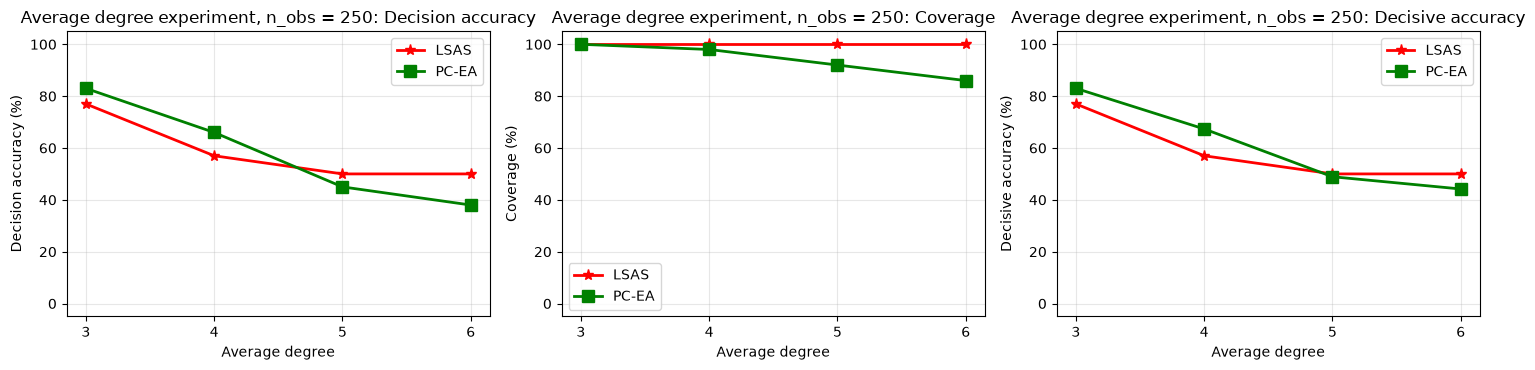

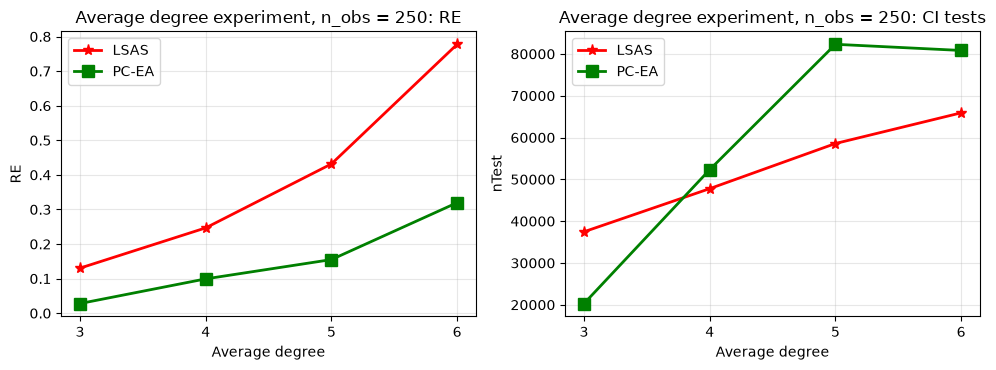

In [130]:
plot_experiment_metrics(
    decision_df=avg_degree_decision_metrics,
    effect_df=avg_degree_effect_effort,
    x_col="avg_degree",
    x_label="Average degree",
    title_prefix=f"Average degree experiment, n_obs = {BASE_N_OBS}",
)


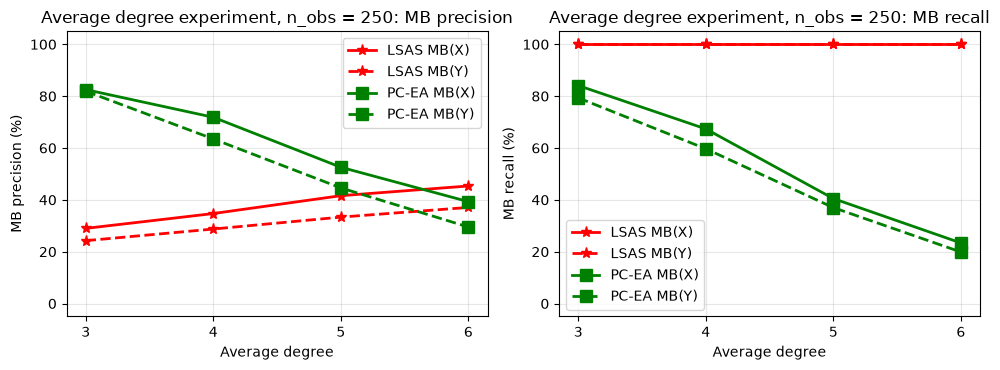

,avg_degree,method,target,n_reps,mean_mb_precision,std_mb_precision,mean_mb_recall,std_mb_recall
0,3,LSAS,X,100,0.289913,0.099691,1.000000,0.000000
1,3,LSAS,Y,100,0.242480,0.079090,1.000000,0.000000
2,3,PC-EA,X,100,0.825218,0.183525,0.840952,0.168966
3,3,PC-EA,Y,100,0.819167,0.218894,0.793333,0.212370
4,4,LSAS,X,100,0.347141,0.113669,1.000000,0.000000
5,4,LSAS,Y,100,0.287376,0.094255,1.000000,0.000000
6,4,PC-EA,X,100,0.718484,0.240742,0.673611,0.265038
7,4,PC-EA,Y,100,0.634833,0.304678,0.597000,0.309514
8,5,LSAS,X,100,0.416020,0.137366,1.000000,0.000000
9,5,LSAS,Y,100,0.333374,0.099103,1.000000,0.000000


In [131]:
avg_degree_mb_comparison, avg_degree_mb_comparison_detail = compare_markov_blankets(
    avg_degree_results,
    group_cols=["avg_degree"],
)

plot_markov_blanket_metrics(
    avg_degree_mb_comparison,
    x_col="avg_degree",
    x_label="Average degree",
    title_prefix=f"Average degree experiment, n_obs = {BASE_N_OBS}",
)

avg_degree_mb_comparison


### 400 Nodes

In [132]:
BASE_N_OBS = 400

In [133]:
avg_degree_results_list = []

for avg_degree in avg_degrees:
    results_one_avg_degree = run_structure_experiment(
        structure_name=f"Average degree experiment, avg_degree={avg_degree}",
        sample_sizes=[BASE_SAMPLE_SIZE],
        n_reps=BASE_N_REPS,
        n_obs=BASE_N_OBS,
        p=p_for_size(BASE_N_OBS, avg_degree=avg_degree),
        beta=BASE_BETA,
        ci_method=BASE_CI_METHOD,
        n_force_x_parents=avg_degree,
        n_force_y_parents=avg_degree,
        max_z_size=MAX_Z_SIZE
        )
    results_one_avg_degree["avg_degree"] = avg_degree
    avg_degree_results_list.append(results_one_avg_degree)

avg_degree_results = pd.concat(avg_degree_results_list, ignore_index=True)
avg_degree_results


Running Average degree experiment, avg_degree=3 with sample size 5000 for 100 reps...


Processing Average degree experiment, avg_degree=3: 100%|██████████| 100/100 [28:58<00:00, 17.38s/it]


Running Average degree experiment, avg_degree=4 with sample size 5000 for 100 reps...


Processing Average degree experiment, avg_degree=4: 100%|██████████| 100/100 [41:13<00:00, 24.73s/it]


Running Average degree experiment, avg_degree=5 with sample size 5000 for 100 reps...


Processing Average degree experiment, avg_degree=5: 100%|██████████| 100/100 [48:26<00:00, 29.07s/it]


Running Average degree experiment, avg_degree=6 with sample size 5000 for 100 reps...


Processing Average degree experiment, avg_degree=6: 100%|██████████| 100/100 [52:24<00:00, 31.44s/it]


,method,structure,sample_size,rep,true_decision,decision,decision_correct,is_decisive,true_ce,estimated_ce,...,MB_y,actual_MB_x,actual_MB_y,x_degree,y_degree,avg_xy_degree,p,beta,noise_scale,avg_degree
0,PC-EA,"Average degree experiment, avg_degree=3",5000,0,+,+,True,True,2.533424,2.546580,...,"[V222, V245, V334]","[V217, V222, V245, V333, V334, V338, outcome]","[V222, V245, V334, treatment]",4,4,4.0,0.007481,0,1.0,3
1,LSAS,"Average degree experiment, avg_degree=3",5000,0,+,+,True,True,2.533424,4.533656,...,"[V10, V42, V86, V88, V143, V167, V187, V191, V...","[V217, V222, V245, V333, V334, V338, outcome]","[V222, V245, V334, treatment]",4,4,4.0,0.007481,0,1.0,3
2,PC-EA,"Average degree experiment, avg_degree=3",5000,1,0,+,False,True,0.000000,-0.076136,...,"[V212, V217, V256, V38]","[V2, V239, V94]","[V212, V217, V38]",3,3,3.0,0.007481,0,1.0,3
3,LSAS,"Average degree experiment, avg_degree=3",5000,1,0,+,False,True,0.000000,-0.052595,...,"[V6, V38, V54, V55, V80, V125, V175, V177, V18...","[V2, V239, V94]","[V212, V217, V38]",3,3,3.0,0.007481,0,1.0,3
4,PC-EA,"Average degree experiment, avg_degree=3",5000,2,+,+,True,True,1.840475,1.825697,...,"[V19, V195, V27, V363]","[V19, V27, V363, V45, V50, V63, outcome]","[V19, V27, V363, treatment]",4,4,4.0,0.007481,0,1.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,LSAS,"Average degree experiment, avg_degree=6",5000,97,0,+,False,True,0.000000,4.366484,...,"[V11, V15, V17, V26, V38, V46, V61, V71, V73, ...","[V204, V250, V266, V29, V344, V85]","[V134, V320, V362, V61, V71, V73]",6,6,6.0,0.014963,0,1.0,6
796,PC-EA,"Average degree experiment, avg_degree=6",5000,98,+,+,True,True,1.958710,2.248342,...,"[V200, V260, V35, V378, V98]","[V104, V140, V177, V19, V227, V239, V280, V297...","[V177, V19, V227, V280, V35, V88, treatment]",7,7,7.0,0.014963,0,1.0,6
797,LSAS,"Average degree experiment, avg_degree=6",5000,98,+,+,True,True,1.958710,3.679153,...,"[V19, V31, V35, V88, V104, V117, V142, V164, V...","[V104, V140, V177, V19, V227, V239, V280, V297...","[V177, V19, V227, V280, V35, V88, treatment]",7,7,7.0,0.014963,0,1.0,6
798,PC-EA,"Average degree experiment, avg_degree=6",5000,99,0,+,False,True,0.000000,0.841580,...,"[V123, V199, V362, V389, V62]","[V103, V113, V135, V229, V30, V352]","[V123, V199, V282, V362, V389, V62]",6,6,6.0,0.014963,0,1.0,6


In [134]:
avg_degree_decision_metrics = (
    avg_degree_results
    .groupby(["method", "avg_degree"], as_index=False)
    .agg(
        decision_acc=("decision_correct", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
)

avg_degree_decisive_metrics = (
    avg_degree_results[avg_degree_results["is_decisive"]]
    .groupby(["method", "avg_degree"], as_index=False)
    .agg(
        decisive_acc=("decision_correct", "mean"),
        n_decisive=("decision", "size"),
    )
)

avg_degree_decision_metrics = avg_degree_decision_metrics.merge(
    avg_degree_decisive_metrics,
    on=["method", "avg_degree"],
    how="left",
)

avg_degree_decision_metrics


,method,avg_degree,decision_acc,coverage,n_reps,decisive_acc,n_decisive
0,LSAS,3,0.80,1.00,100,0.800000,100
1,LSAS,4,0.53,1.00,100,0.530000,100
2,LSAS,5,0.50,1.00,100,0.500000,100
3,LSAS,6,0.50,1.00,100,0.500000,100
4,PC-EA,3,0.90,0.99,100,0.909091,99
5,PC-EA,4,0.71,1.00,100,0.710000,100
6,PC-EA,5,0.46,0.93,100,0.494624,93
7,PC-EA,6,0.44,0.90,100,0.488889,90


In [135]:
avg_degree_effect_effort = (
    avg_degree_results
    .groupby(["method", "avg_degree"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

avg_degree_effect_effort


,method,avg_degree,mean_RE,std_RE,mean_nTest,std_nTest
0,LSAS,3,0.063536,0.129168,195421.49,150417.157152
1,LSAS,4,0.243162,0.319178,229532.88,190271.066539
2,LSAS,5,0.470193,0.572491,231064.90,153191.977615
3,LSAS,6,1.127393,1.890517,266211.19,188748.103705
4,PC-EA,3,0.011922,0.019191,26594.26,17120.139226
5,PC-EA,4,0.085247,0.114977,101257.59,45493.187158
6,PC-EA,5,0.151479,0.188769,165760.63,57068.786784
7,PC-EA,6,0.264209,0.318515,163353.34,36649.010145


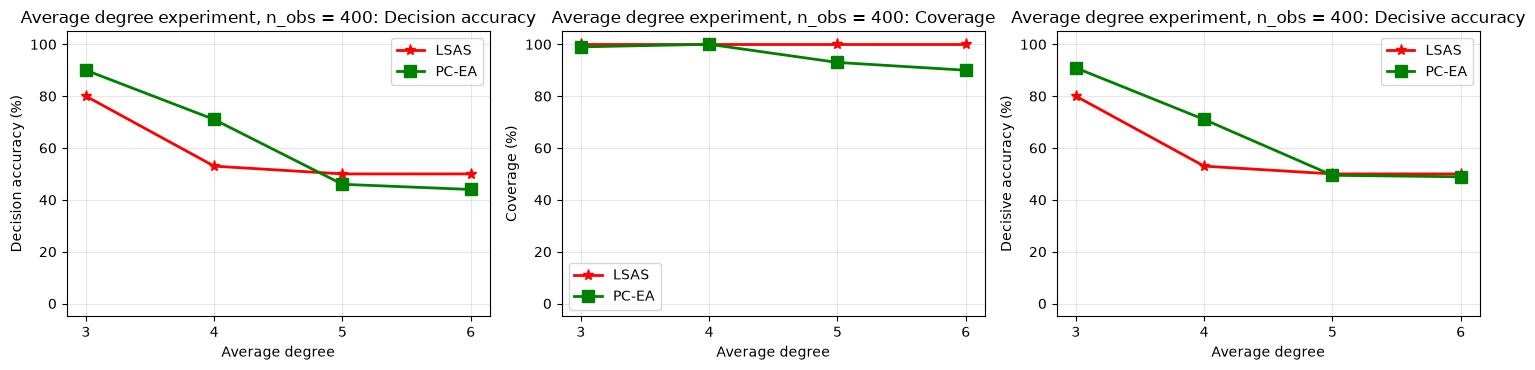

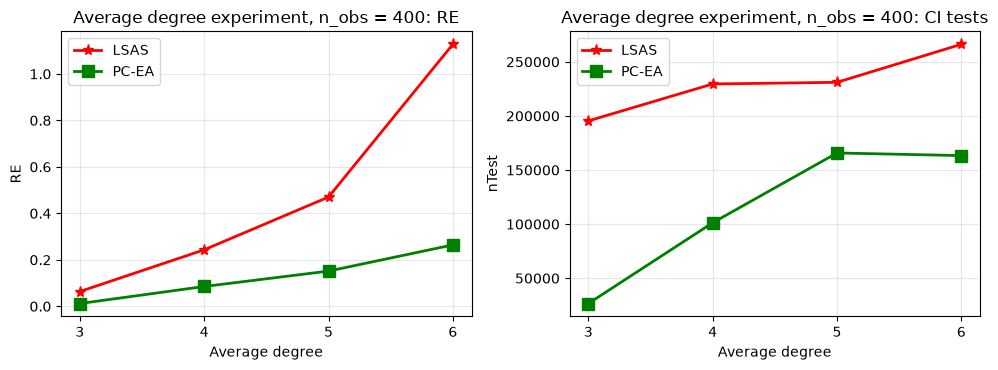

In [136]:
plot_experiment_metrics(
    decision_df=avg_degree_decision_metrics,
    effect_df=avg_degree_effect_effort,
    x_col="avg_degree",
    x_label="Average degree",
    title_prefix=f"Average degree experiment, n_obs = {BASE_N_OBS}",
)


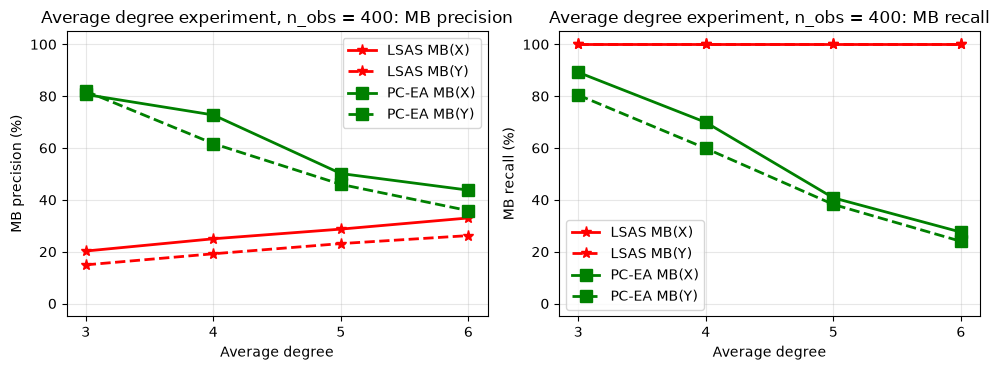

,avg_degree,method,target,n_reps,mean_mb_precision,std_mb_precision,mean_mb_recall,std_mb_recall
0,3,LSAS,X,100,0.202501,0.078070,1.000000,0.000000
1,3,LSAS,Y,100,0.149175,0.035176,1.000000,0.000000
2,3,PC-EA,X,100,0.806393,0.179712,0.891905,0.130516
3,3,PC-EA,Y,100,0.819452,0.209171,0.804167,0.187792
4,4,LSAS,X,100,0.249765,0.092603,1.000000,0.000000
5,4,LSAS,Y,100,0.191908,0.058784,1.000000,0.000000
6,4,PC-EA,X,100,0.727383,0.239900,0.698889,0.248725
7,4,PC-EA,Y,100,0.616976,0.296333,0.598500,0.287488
8,5,LSAS,X,100,0.287059,0.098391,1.000000,0.000000
9,5,LSAS,Y,100,0.231233,0.056901,1.000000,0.000000


In [137]:
avg_degree_mb_comparison, avg_degree_mb_comparison_detail = compare_markov_blankets(
    avg_degree_results,
    group_cols=["avg_degree"],
)

plot_markov_blanket_metrics(
    avg_degree_mb_comparison,
    x_col="avg_degree",
    x_label="Average degree",
    title_prefix=f"Average degree experiment, n_obs = {BASE_N_OBS}",
)

avg_degree_mb_comparison


## Nonlinearity Experiment


In [138]:
BASE_N_OBS = 100
BASE_P = TARGET_AVG_DEGREE / (BASE_N_OBS + 1)

In [139]:
beta_results_list = []

for beta_value in beta_values:
    results_one_beta = run_structure_experiment(
        structure_name=f"Nonlinearity experiment, beta={beta_value}",
        sample_sizes=[BASE_SAMPLE_SIZE],
        n_reps=BASE_N_REPS,
        n_obs=BASE_N_OBS,
        p=BASE_P,
        beta=beta_value,
        ci_method=BASE_CI_METHOD,
        n_force_x_parents=N_FORCE_X_PARENTS,
        n_force_y_parents=N_FORCE_Y_PARENTS,
        max_z_size=MAX_Z_SIZE
        )
    results_one_beta["beta_value"] = beta_value
    beta_results_list.append(results_one_beta)

beta_results = pd.concat(beta_results_list, ignore_index=True)
beta_results


Running Nonlinearity experiment, beta=0 with sample size 5000 for 100 reps...


Processing Nonlinearity experiment, beta=0: 100%|██████████| 100/100 [01:19<00:00,  1.25it/s]


Running Nonlinearity experiment, beta=0.5 with sample size 5000 for 100 reps...


Processing Nonlinearity experiment, beta=0.5: 100%|██████████| 100/100 [41:28<00:00, 24.88s/it] 


Running Nonlinearity experiment, beta=1 with sample size 5000 for 100 reps...


Processing Nonlinearity experiment, beta=1: 100%|██████████| 100/100 [53:46<00:00, 32.26s/it] 


,method,structure,sample_size,rep,true_decision,decision,decision_correct,is_decisive,true_ce,estimated_ce,...,MB_y,actual_MB_x,actual_MB_y,x_degree,y_degree,avg_xy_degree,p,beta,noise_scale,beta_value
0,PC-EA,"Nonlinearity experiment, beta=0",5000,0,+,+,True,True,1.981064,1.980462,...,"[V37, V52, V59]","[V1, V37, V50, V52, V59, V96, outcome]","[V37, V52, V59, treatment]",4,4,4.0,0.029703,0.0,1.0,0.0
1,LSAS,"Nonlinearity experiment, beta=0",5000,0,+,+,True,True,1.981064,1.981094,...,"[V11, V13, V37, V52, V56, V59, V78, V96, treat...","[V1, V37, V50, V52, V59, V96, outcome]","[V37, V52, V59, treatment]",4,4,4.0,0.029703,0.0,1.0,0.0
2,PC-EA,"Nonlinearity experiment, beta=0",5000,1,0,0,True,True,0.000000,0.000000,...,"[V4, V74, V94]","[V36, V78, V83]","[V4, V74, V94]",3,3,3.0,0.029703,0.0,1.0,0.0
3,LSAS,"Nonlinearity experiment, beta=0",5000,1,0,0,True,True,0.000000,0.000000,...,"[V2, V4, V49, V63, V74, V75, V94]","[V36, V78, V83]","[V4, V74, V94]",3,3,3.0,0.029703,0.0,1.0,0.0
4,PC-EA,"Nonlinearity experiment, beta=0",5000,2,+,+,True,True,1.469639,1.885753,...,"[V0, V30, V37]","[V15, V21, V37, V68, V88, V91, outcome]","[V37, V68, V91, treatment]",4,4,4.0,0.029703,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,LSAS,"Nonlinearity experiment, beta=1",5000,97,0,0,True,True,0.050008,0.000000,...,"[V3, V7, V15, V51, V65, V67, V73]","[V13, V18, V74]","[V3, V65, V73]",3,3,3.0,0.029703,1.0,1.0,1.0
596,PC-EA,"Nonlinearity experiment, beta=1",5000,98,+,+,True,True,0.686400,0.861604,...,"[V18, V59, V68, V78, V79]","[V15, V18, V26, V46, V59, V79, outcome]","[V18, V59, V79, treatment]",4,4,4.0,0.029703,1.0,1.0,1.0
597,LSAS,"Nonlinearity experiment, beta=1",5000,98,+,+,True,True,0.686400,0.866500,...,"[V18, V42, V43, V59, V62, V68, V75, V79, treat...","[V15, V18, V26, V46, V59, V79, outcome]","[V18, V59, V79, treatment]",4,4,4.0,0.029703,1.0,1.0,1.0
598,PC-EA,"Nonlinearity experiment, beta=1",5000,99,0,0,True,True,0.008641,0.000000,...,"[V19, V3, V50, V67, V7, V76, V81]","[V13, V29, V88]","[V19, V50, V81]",3,3,3.0,0.029703,1.0,1.0,1.0


In [140]:
beta_decision_metrics = (
    beta_results
    .groupby(["method", "beta_value"], as_index=False)
    .agg(
        decision_acc=("decision_correct", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
)

beta_decisive_metrics = (
    beta_results[beta_results["is_decisive"]]
    .groupby(["method", "beta_value"], as_index=False)
    .agg(
        decisive_acc=("decision_correct", "mean"),
        n_decisive=("decision", "size"),
    )
)

beta_decision_metrics = beta_decision_metrics.merge(
    beta_decisive_metrics,
    on=["method", "beta_value"],
    how="left",
)

beta_decision_metrics["n_decisive"] = beta_decision_metrics["n_decisive"].fillna(0).astype(int)

beta_decision_metrics


,method,beta_value,decision_acc,coverage,n_reps,decisive_acc,n_decisive
0,LSAS,0.0,0.79,1.00,100,0.79000,100
1,LSAS,0.5,0.75,1.00,100,0.75000,100
2,LSAS,1.0,0.98,1.00,100,0.98000,100
3,PC-EA,0.0,0.81,0.96,100,0.84375,96
4,PC-EA,0.5,0.83,1.00,100,0.83000,100
5,PC-EA,1.0,0.98,1.00,100,0.98000,100


In [141]:
beta_effect_effort = (
    beta_results
    .groupby(["method", "beta_value"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

beta_effect_effort


,method,beta_value,mean_RE,std_RE,mean_nTest,std_nTest
0,LSAS,0.0,0.177935,0.393547,2968.97,3321.379382
1,LSAS,0.5,5.317379,19.797644,3167.85,3439.100947
2,LSAS,1.0,0.771634,1.812951,2933.71,2289.253653
3,PC-EA,0.0,0.099910,0.264283,7970.60,5024.048914
4,PC-EA,0.5,3.629265,19.295913,8725.66,6652.960222
5,PC-EA,1.0,0.724053,1.399554,8412.11,5190.580701


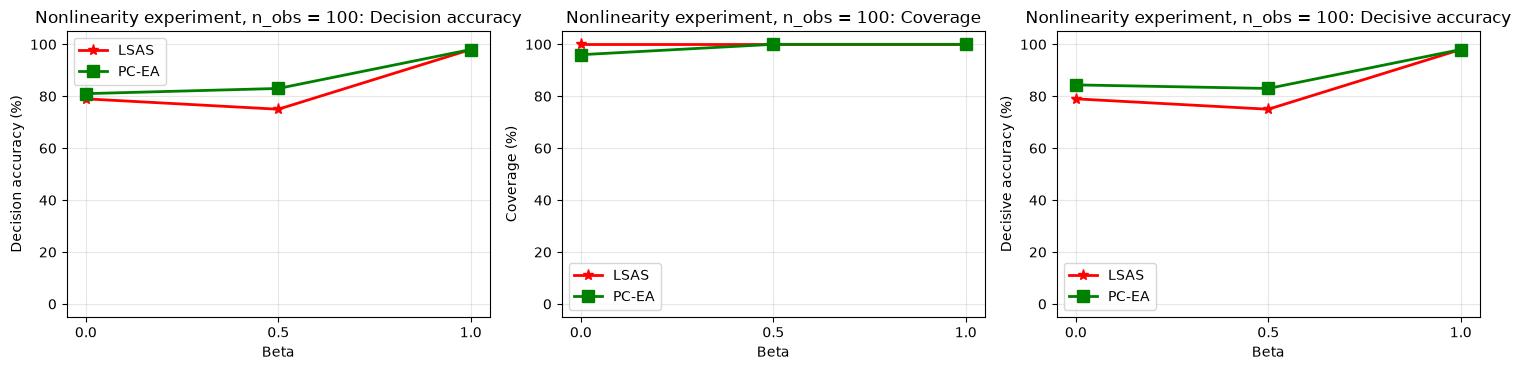

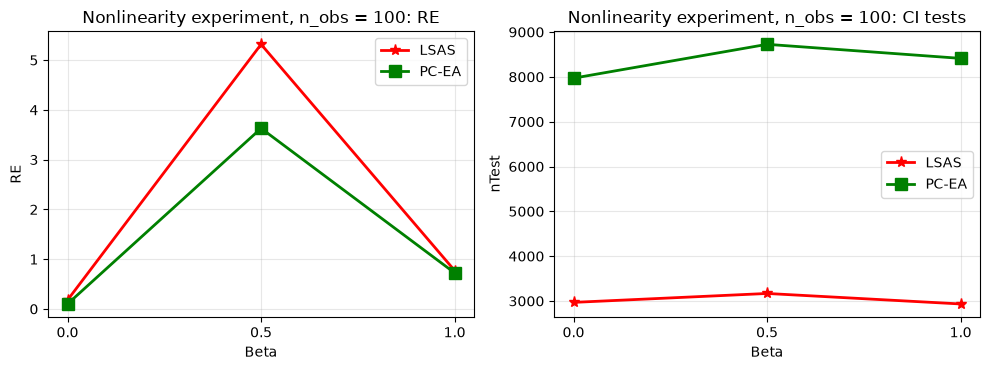

In [142]:
plot_experiment_metrics(
    decision_df=beta_decision_metrics,
    effect_df=beta_effect_effort,
    x_col="beta_value",
    x_label="Beta",
    title_prefix=f"Nonlinearity experiment, n_obs = {BASE_N_OBS}",
)


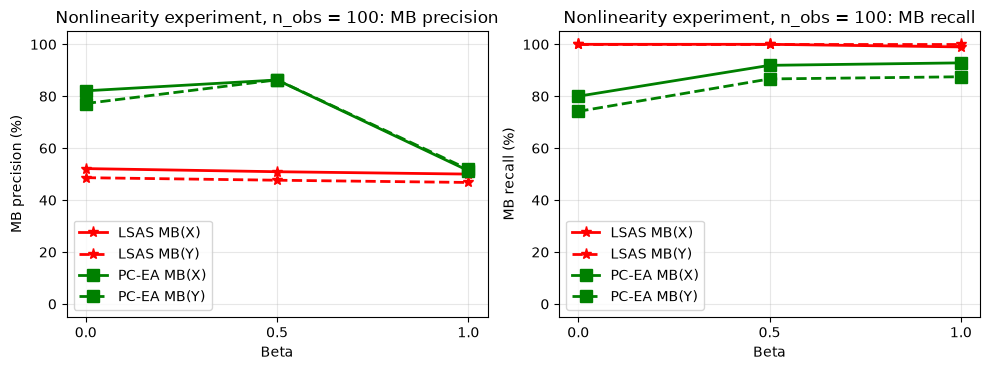

,beta_value,method,target,n_reps,mean_mb_precision,std_mb_precision,mean_mb_recall,std_mb_recall
0,0.0,LSAS,X,100,0.521364,0.185639,1.000000,0.000000
1,0.0,LSAS,Y,100,0.486325,0.166771,1.000000,0.000000
2,0.0,PC-EA,X,100,0.820877,0.216637,0.800000,0.209161
3,0.0,PC-EA,Y,100,0.772024,0.255519,0.741667,0.241436
4,0.5,LSAS,X,100,0.509310,0.169413,1.000000,0.000000
5,0.5,LSAS,Y,100,0.476582,0.161693,1.000000,0.000000
6,0.5,PC-EA,X,100,0.862631,0.139636,0.919048,0.084671
7,0.5,PC-EA,Y,100,0.863119,0.159469,0.866667,0.136083
8,1.0,LSAS,X,100,0.500173,0.174895,0.990000,0.036633
9,1.0,LSAS,Y,100,0.467952,0.151872,1.000000,0.000000


In [143]:
beta_mb_comparison, beta_mb_comparison_detail = compare_markov_blankets(
    beta_results,
    group_cols=["beta_value"],
)

plot_markov_blanket_metrics(
    beta_mb_comparison,
    x_col="beta_value",
    x_label="Beta",
    title_prefix=f"Nonlinearity experiment, n_obs = {BASE_N_OBS}",
)

beta_mb_comparison
